#**Projet 1 : Prédiction du succès d’une campagne marketing bancaire**

***Travail realisé par  :***   

- Cedric enzo Kouokam Kamhoua,




**Contexte:**

*Une banque lance régulièrement des campagnes téléphoniques pour proposer un produit d’épargne à ses clients.*

*Elle souhaite :*
- *comprendre quels profils répondent positivement*
- *identifier les facteurs influençant la décision*
- *prédire quels clients contacter pour optimiser les coûts.*

# **1. Exploration du dataset**


##Install & import

In [ ]:
# Import des lib
!pip install kagglehub
!pip install imbalanced-learn

In [ ]:
# import lib
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import seaborn as sns

import kagglehub
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.linear_model import LogisticRegression

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import GridSearchCV


from imblearn.over_sampling import SMOTE
from collections import Counter

from sklearn.pipeline import Pipeline

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
# Thème global pour les graphs
sns.set_palette("pastel")

## Chargement du dataset & création du DF

In [ ]:
# Téléchargement & chargement du dataset

path = kagglehub.dataset_download("adityamhaske/bank-marketing-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'bank-marketing-dataset' dataset.
Path to dataset files: /kaggle/input/bank-marketing-dataset


In [ ]:
os.listdir(path)

['bank.csv', 'bank-full.csv']

In [ ]:
df = pd.read_csv(path + "/bank-full.csv", sep=";")
df_nofull = pd.read_csv(path + "/bank.csv", sep=";")


##Vue d'ensemble

In [ ]:
df.head()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


- Le jeu de données contient 45 211 lignes et 17 colonnes. Toutes les colonnes sont non nulles, donc pas de valeurs manquantes à ce stade.
- Types : 7 variables numériques et 10 variables catégorielles.


In [ ]:
df.nunique()

,0
age,77
job,12
marital,3
education,4
default,2
balance,7168
housing,2
loan,2
contact,3
day,31


In [ ]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


1. **Qualité des données:**

Sur l’instantané analysé, il n’y a pas de valeurs manquantes dans les colonnes. À ce stade, le dataset semble donc propre sur cet aspect.

2. **Types de variables :**

On observe un mélange de variables numériques et catégorielles.
Pour pouvoir entraîner des modèles de machine learning, il faudra encoder les variables catégorielles (par exemple avec un one-hot encoding).

3. **Variable cible :**

La variable cible Y est binaire (oui / non).
Cela correspond à un problème de classification binaire. Une régression logistique pourrait être un premier modèle pertinent à tester, car elle est adaptée à ce type de problématique et reste facilement interprétable.

4. **Distributions et valeurs extrêmes :**

Certaines variables présentent des valeurs maximales très élevées, notamment : balance,
duration,
campaign,
pdays,
previous.
Il est probable qu’il y ait des outliers ou des distributions fortement asymétriques. Un travail de visualisation sera nécessaire pour mieux comprendre ces distributions et décider s’il faut appliquer des transformations (normalisation).

5. **Cas particulier : pdays**

La variable pdays a une valeur minimale de -1.
Cela signifie que le client n’a jamais été contacté auparavant. Il ne faudra donc pas traiter cette valeur comme un nombre classique, mais plutôt comme une catégorie.

6. **Variable duration :**

La variable duration varie fortement, ce qui montre une forte dispersion.
La médiane est de 180 secondes. Cette variable semble potentiellement très discriminante, mais elle devra être analysée plus en détail.

7. **Profil (médianes) :**

Âge médian : 39 ans
Solde médian : 448
Durée d’appel médiane : 180 secondes
Nombre médian de contacts pendant la campagne : 2


In [ ]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [ ]:
len(df.columns)

17

In [ ]:
df["y"].value_counts()

,count
y,
no,39922
yes,5289


Avant de commencer l’analyse exploratoire, nous avons procédé à une inspection du dataset afin de comprendre sa structure, identifier les types de variables et vérifier la présence éventuelle de valeurs manquantes ou de doublons

# **2. EDA (Exploratory Data Analysis)**


## **A) Analyse Univariée**


In [ ]:
# on sépare les vars restantes -> cat et num
numeric_cols = ["age", "balance", "day", "duration", "campaign", "pdays", "previous"]
categorical_cols = ["job", "marital", "education", "default", "housing", "loan", "contact", "month", "poutcome"]

### Les variables numériques

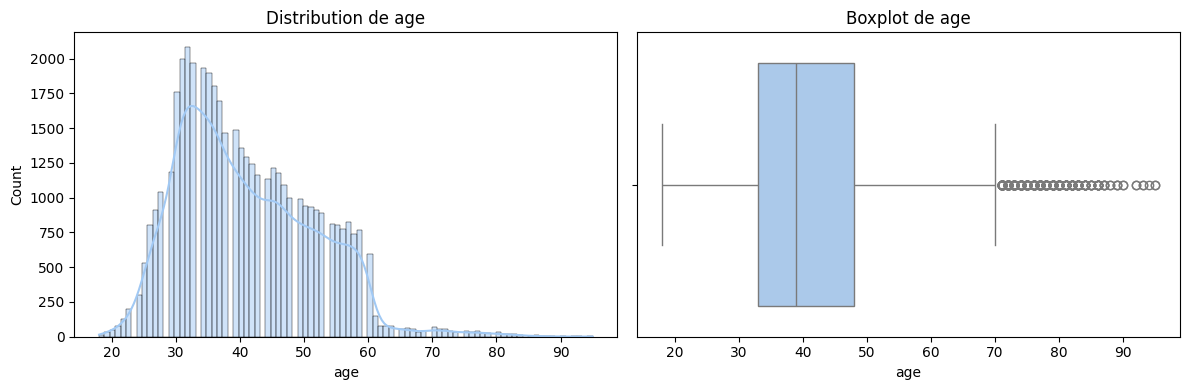

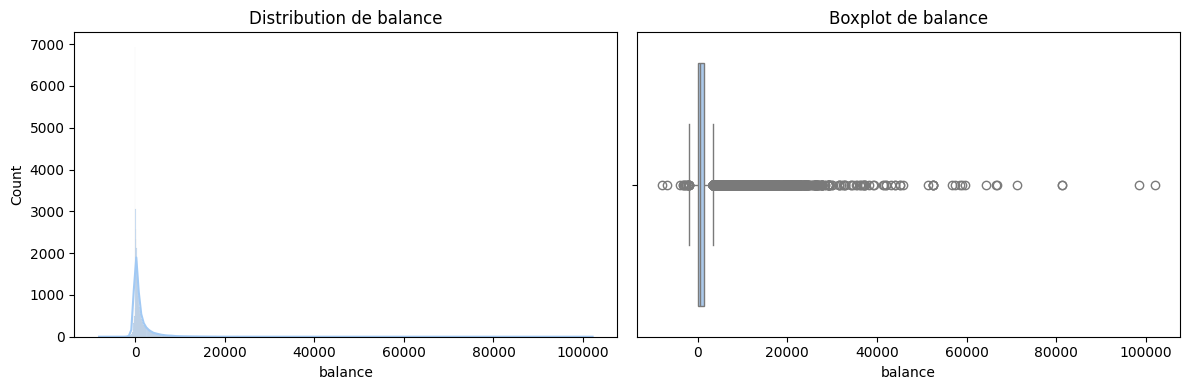

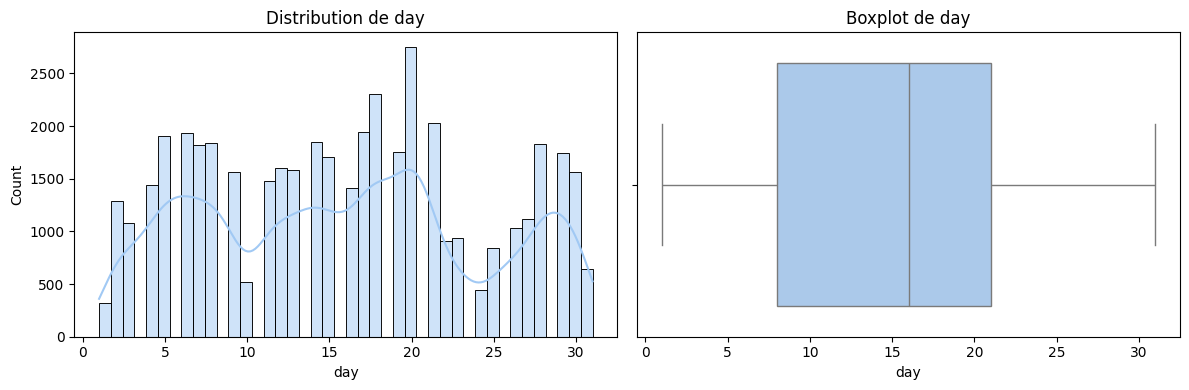

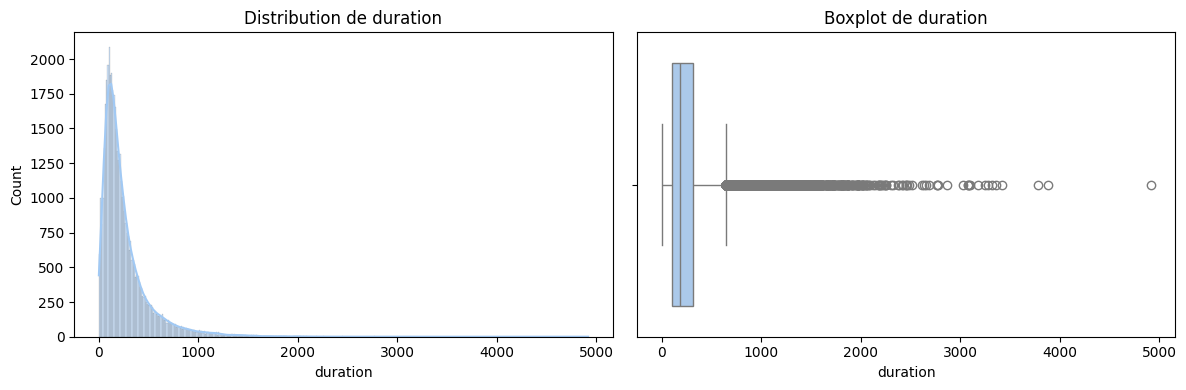

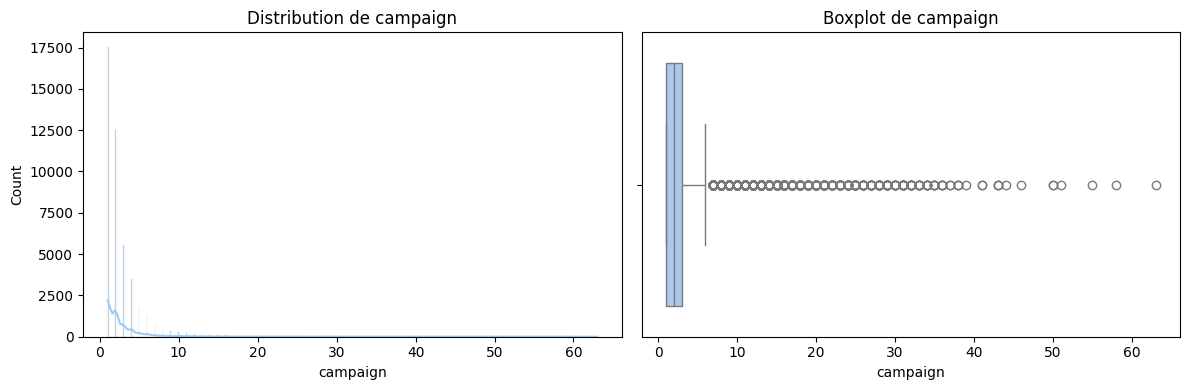

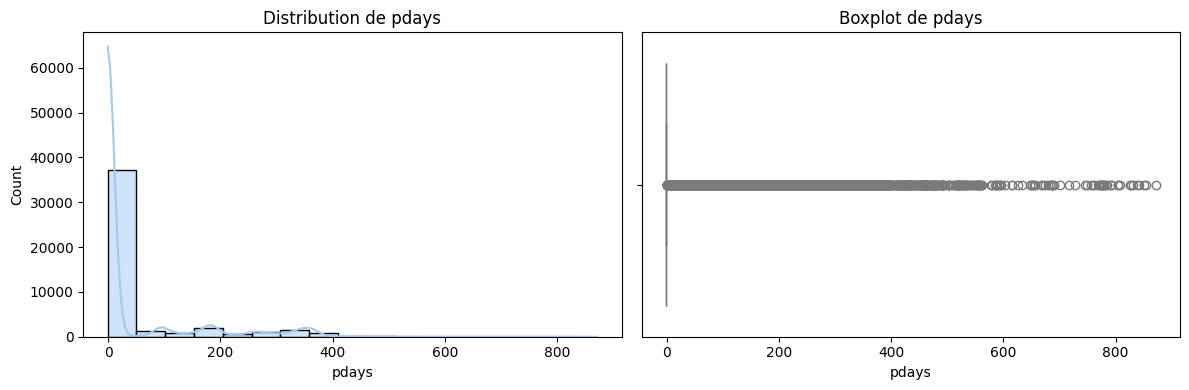

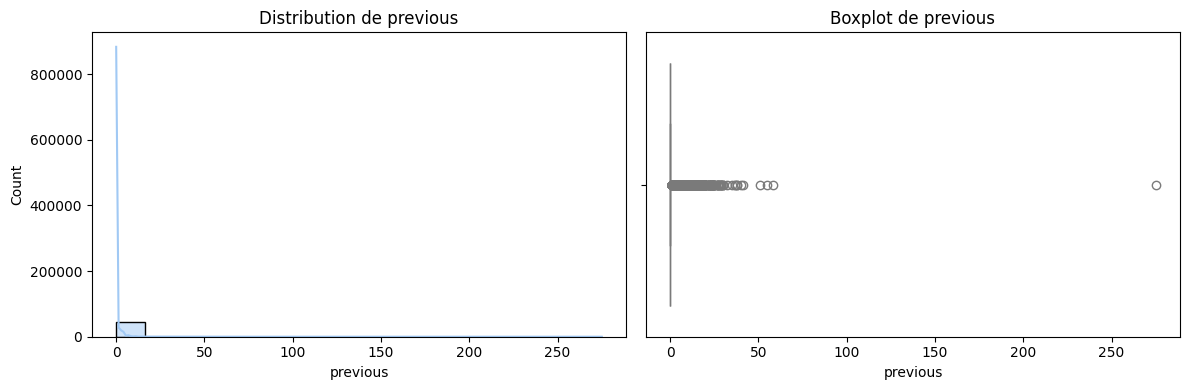

In [ ]:
# graphs des vars num
for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f"Distribution de {col}")
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f"Boxplot de {col}")
    plt.tight_layout()
    plt.show()

- Age :

Distribution est relativement équilibrée autour de 30–40 ans, avec une légère asymétrie à droite. Quelques valeurs élevées sont présentes mais restent marginales.

- Balance :

Distribution très asymétrique à droite avec de nombreux outliers. La majorité des clients ont un solde faible, tandis qu’une minorité présente des montants très élevés.

- Day :

Répartition assez homogène sur les jours du mois. Aucun déséquilibre ou anomalie notable.

- Duration :

Variable fortement asymétrique avec beaucoup d’appels courts et quelques très longs. Les valeurs extrêmes sont nombreuses et peuvent influencer la modélisation.

- Campaign :

La plupart des clients sont contactés peu de fois (1 à 5).

- Pdays :

Forte concentration sur une valeur dominante (souvent 0). Distribution très déséquilibrée nécessitant un traitement spécifique.

- Previous :

Grande majorité de 0 et quelques valeurs élevées. Variable très asymétrique, probablement à transformer ou regrouper.


## Mesure de l’asymétrie (Skewness)

Le skewness (coefficient d’asymétrie) est une mesure statistique qui permet d’évaluer le degré de dissymétrie d’une distribution par rapport à sa moyenne. Concrètement, il indique si les valeurs sont réparties de manière équilibrée autour de la moyenne ou si elles présentent une queue plus longue d’un côté.

- skew = 0 → symétrique
- skew > 0 → asymétrique à droite
- skew < 0 → asymétrique à gauche

ET

- skew > 1 → très asymétrique
- skew > 2 → extrêmement asymétrique

In [ ]:
df[numeric_cols].skew()

,0
age,0.684818
balance,8.360308
day,0.093079
duration,3.144318
campaign,4.898650
pdays,2.615715
previous,41.846454


- Age : équilibrée

- Balance : Extrêmement asymétrique car >2

- Day : équilibrée

- Duration : extrêmement asymétrique

- Campaign : extrêmement asymétrique

- pdays : extrêmement asymétrique

- Previous :extrêmement asymétrique ++

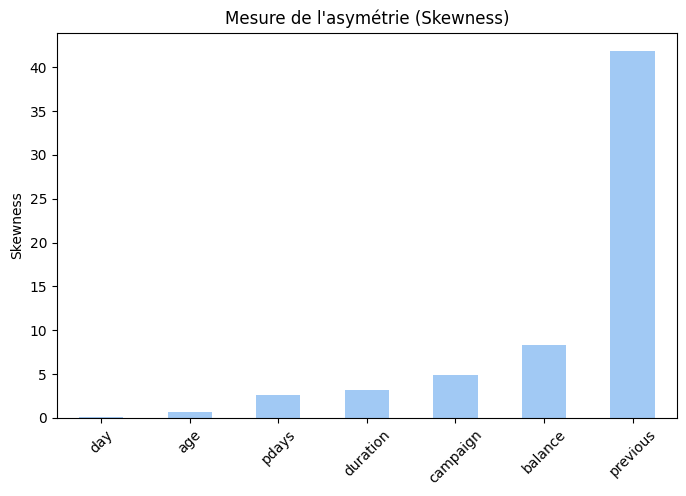

In [ ]:
skew_values = df[numeric_cols].skew()

plt.figure(figsize=(8,5))
skew_values.sort_values().plot(kind='bar')
plt.title("Mesure de l'asymétrie (Skewness)")
plt.ylabel("Skewness")
plt.xticks(rotation=45)
plt.show()

#### Conclusion sur les variables numériques


Les variables numériques présentent globalement une forte asymétrie et de nombreux outliers (notamment balance, duration, campaign). On observe aussi des valeurs particulières comme pdays = -1 (jamais contacté). Ces éléments suggèrent des transformations possibles (log, winsorisation) et un traitement spécifique des codes spéciaux avant la modélisation.

### Les variables catégorielles

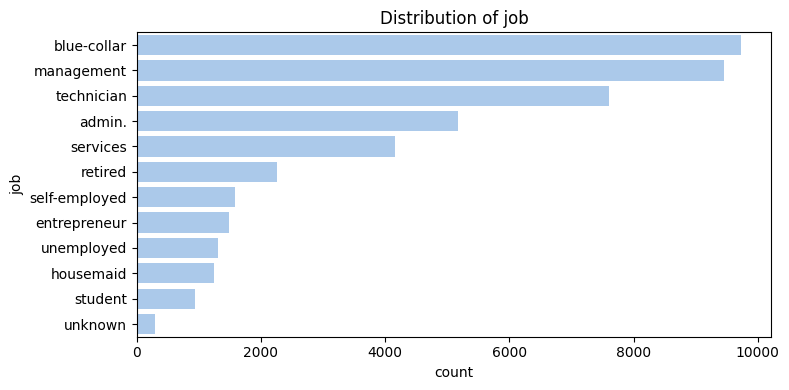

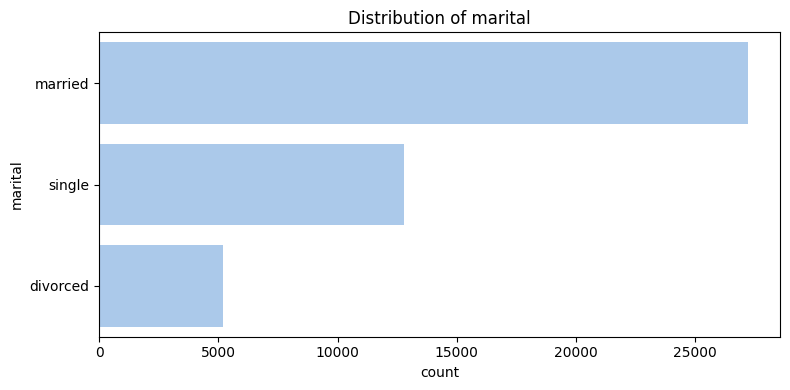

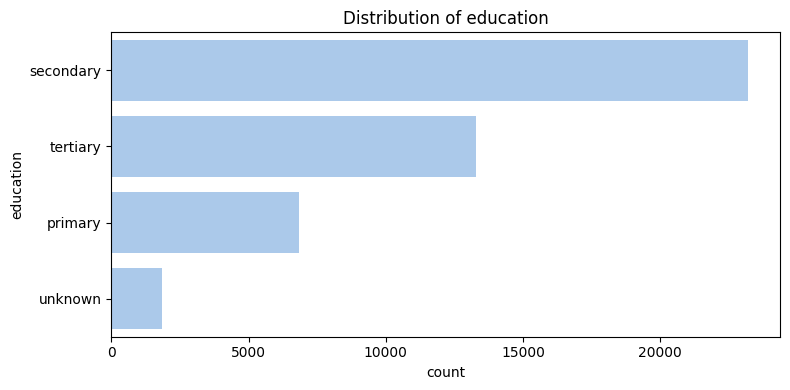

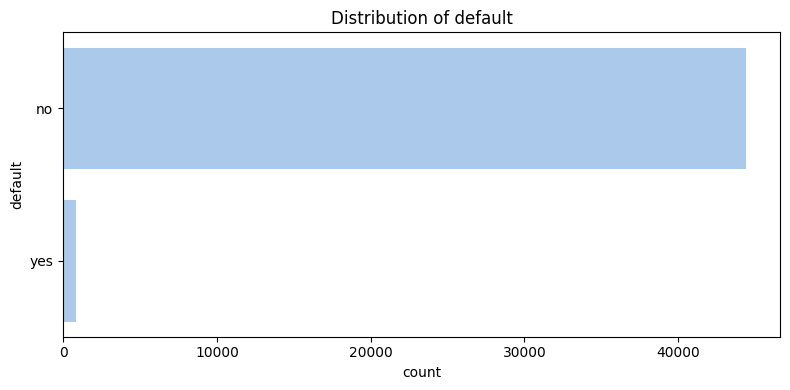

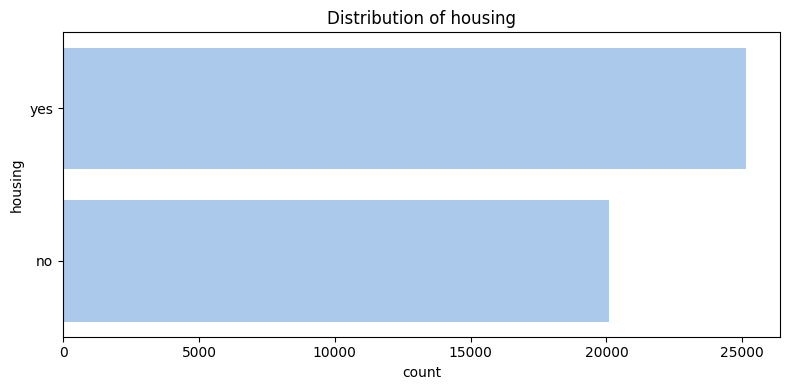

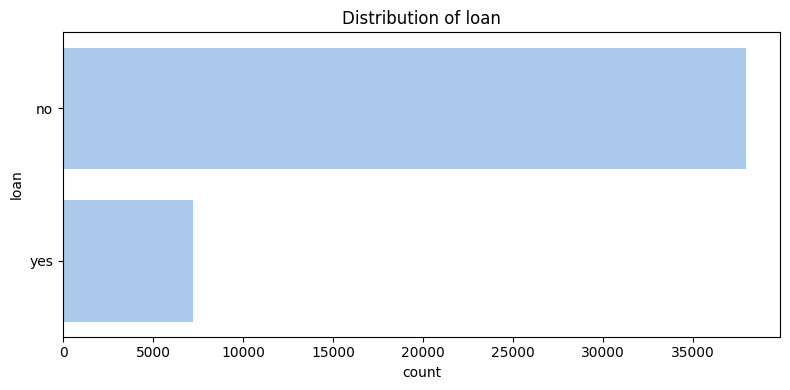

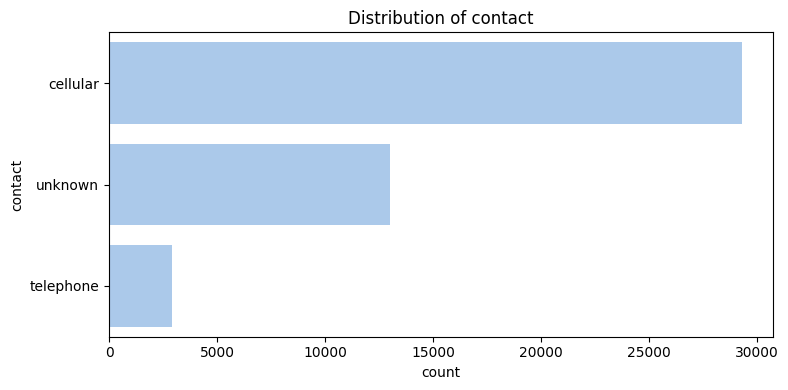

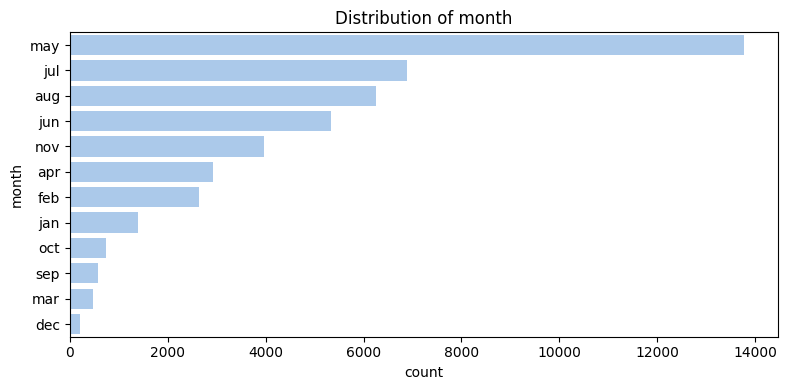

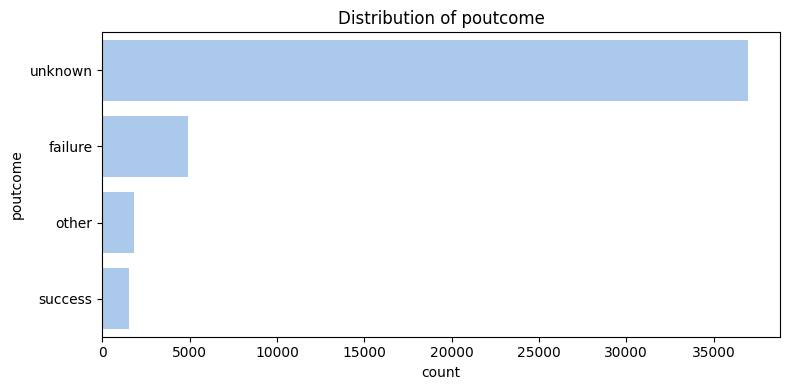

In [ ]:
# distrib des cats
for col in categorical_cols:
    plt.figure(figsize=(8,4))
    order = df[col].value_counts().index
    sns.countplot(y=col, data=df, order=order)
    plt.title(f"Distribution of {col}")
    plt.xlabel("count")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


In [ ]:
for col in categorical_cols:
    print("\nVariable :", col)
    print((df[col].value_counts(normalize=True)*100).round(2))


Variable : job
job
blue-collar      21.53
management       20.92
technician       16.80
admin.           11.44
services          9.19
retired           5.01
self-employed     3.49
entrepreneur      3.29
unemployed        2.88
housemaid         2.74
student           2.07
unknown           0.64
Name: proportion, dtype: float64

Variable : marital
marital
married     60.19
single      28.29
divorced    11.52
Name: proportion, dtype: float64

Variable : education
education
secondary    51.32
tertiary     29.42
primary      15.15
unknown       4.11
Name: proportion, dtype: float64

Variable : default
default
no     98.2
yes     1.8
Name: proportion, dtype: float64

Variable : housing
housing
yes    55.58
no     44.42
Name: proportion, dtype: float64

Variable : loan
loan
no     83.98
yes    16.02
Name: proportion, dtype: float64

Variable : contact
contact
cellular     64.77
unknown      28.80
telephone     6.43
Name: proportion, dtype: float64

Variable : month
month
may    30.45
jul    

- Job : majorité de blue-collar, management, technician

- Marital : majorité de Married

- Education : majorité de Secondary / Présence de Unknown → pas bonne qualité

- Default : Écrasante majorité de No

- Housing : La majorité des clients ont un crédit immobilier

- Loan : Beaucoup de No -> Peu de clients ont un prêt personnel

- Contact : Majorité de cellular / Présence de Unknown → pas bonne qualité

- Month : Pic très marqué en Mai -> Possible saisonnalité à analyser?

- Poutcome : Très majoritairement unknown -> La majorité des clients n'ont pas d’historique de campagne.

- Y : Le dataset est fortement déséquilibré

#### Conclusion sur les variables catégorielles :    

La variable job est principalement composée de blue-collar, management et technician, ce qui montre une concentration sur quelques profils professionnels. La majorité des clients sont mariés, et le niveau d’éducation dominant est secondary.
La variable default est très déséquilibrée (quasi uniquement no). Plus de la moitié des clients ont un crédit immobilier, tandis que peu ont un prêt personnel.
Le contact se fait majoritairement par cellular, mais la présence de nombreuses modalités unknown (notamment pour education, contact et poutcome) indique une qualité de données imparfaite.
On observe également une forte concentration des campagnes en mai, suggérant une possible saisonnalité.

Enfin, la cible est déséquilibrée, ce qui devra être pris en compte en modélisation.

### ***Conclusion analyse univariée :***

L’analyse univariée des variables catégorielles met en évidence plusieurs déséquilibres importants entre les modalités. Certaines variables comme default, poutcome et la variable cible y présentent une forte asymétrie, avec une classe dominante. La clientèle est majoritairement composée d’individus mariés, de niveau d’éducation secondaire et travaillant principalement dans les secteurs blue-collar ou management. La campagne semble concentrée sur certains mois, notamment en mai. Le déséquilibre marqué de la variable cible devra être pris en compte lors de la modélisation.

**Points de vigilance cas pour les cas spéciaux**

duration  variable connue après l’appel  risque de fuite d’information si l’objectif est de prédire avant contact. À exclure du modèle “pré‑appel”, mais utile pour analyse post‑appel.

pdays = -1 : code spécial indiquant “jamais contacté”. À traiter comme une valeur distincte et non comme un vrai jour.

Valeurs unknown : ce ne sont pas des manquants mais une catégorie informative. On les conserve comme catégorie (au moins au départ).

day et month : day est un jour du mois (pas une vraie date) → on peut le traiter comme variable discrète, mais sans interprétation temporelle forte.

balance négatif : distribution très asymétrique → vérifier l’impact sur les modèles.

## **B) Analyse Bivariée**


## Comparaison des variables numériques selon la variable cible

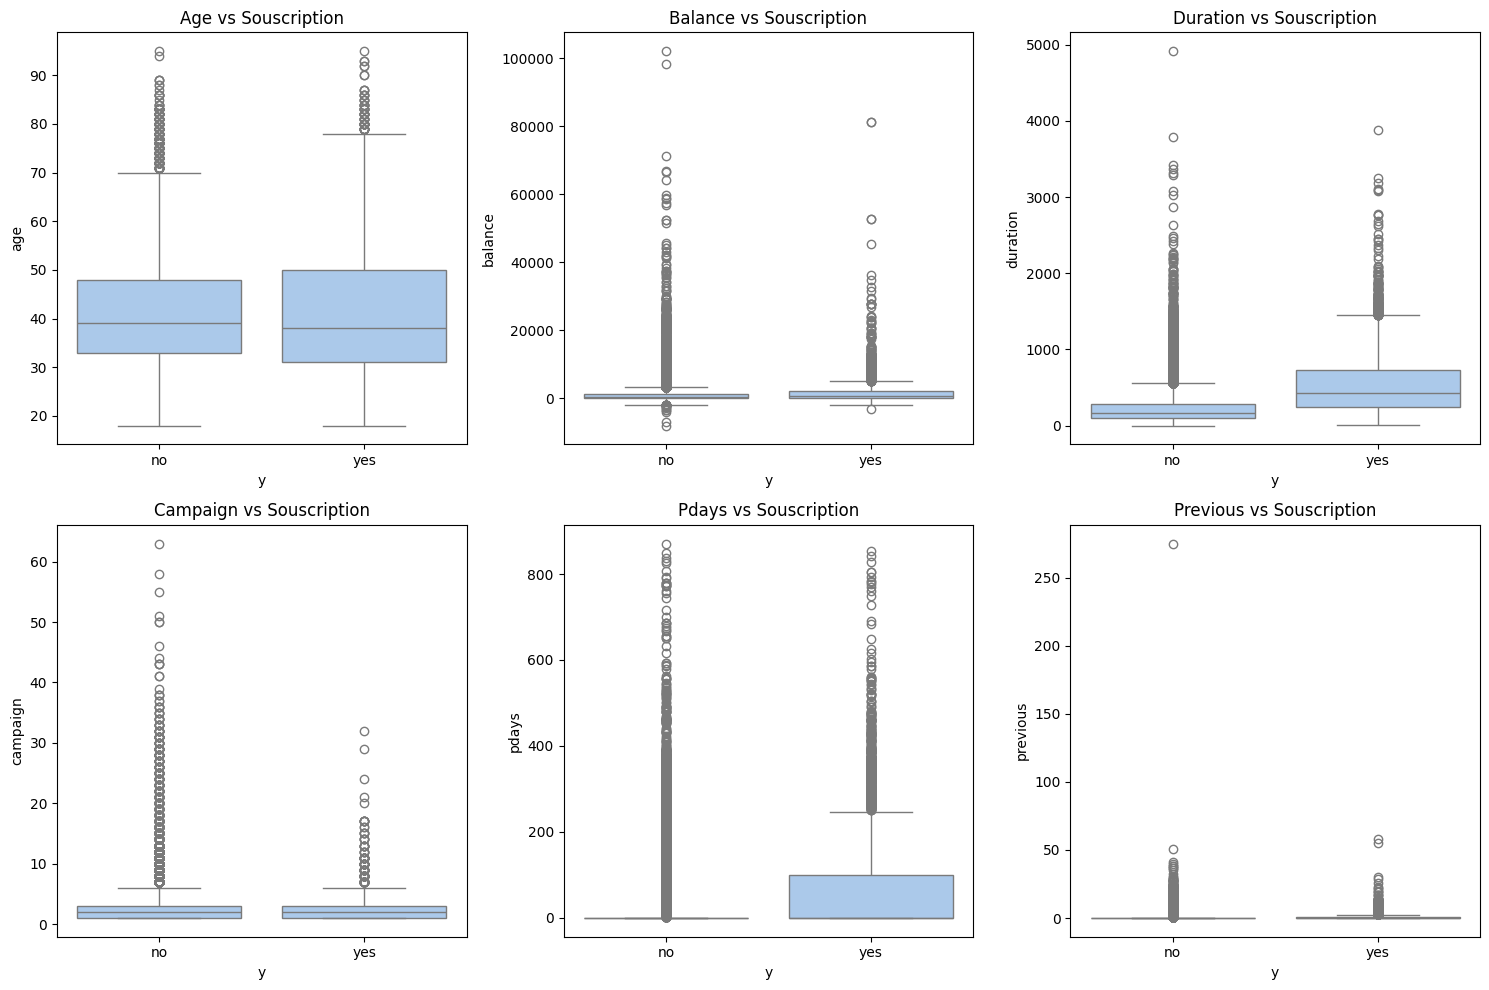

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15,10))

sns.boxplot(x="y", y="age", data=df, ax=axes[0,0])
axes[0,0].set_title("Age vs Souscription")

sns.boxplot(x="y", y="balance", data=df, ax=axes[0,1])
axes[0,1].set_title("Balance vs Souscription")

sns.boxplot(x="y", y="duration", data=df, ax=axes[0,2])
axes[0,2].set_title("Duration vs Souscription")

sns.boxplot(x="y", y="campaign", data=df, ax=axes[1,0])
axes[1,0].set_title("Campaign vs Souscription")

sns.boxplot(x="y", y="pdays", data=df, ax=axes[1,1])
axes[1,1].set_title("Pdays vs Souscription")

sns.boxplot(x="y", y="previous", data=df, ax=axes[1,2])
axes[1,2].set_title("Previous vs Souscription")

plt.tight_layout()
plt.show()

## Visualisation des distributions conditionnelles (Violin plots)

*Pourquoi Violin plots?*

*Pour voir :*
- *la médiane (si inner="box"),*
- *la dispersion,*
- *la densité complète de la distribution.*

*Donc cette section permet d’analyser plus finement la forme des distributions selon la classe de y.*

/tmp/ipykernel_226/1567832806.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="y", y="age", data=df, ax=axes[0,0], palette="magma", inner="box")
/tmp/ipykernel_226/1567832806.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="y", y="balance", data=df, ax=axes[0,1], palette="magma")
/tmp/ipykernel_226/1567832806.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="y", y="duration", data=df, ax=axes[0,2], palette="magma")
/tmp/ipykernel_226/1567832806.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is dep

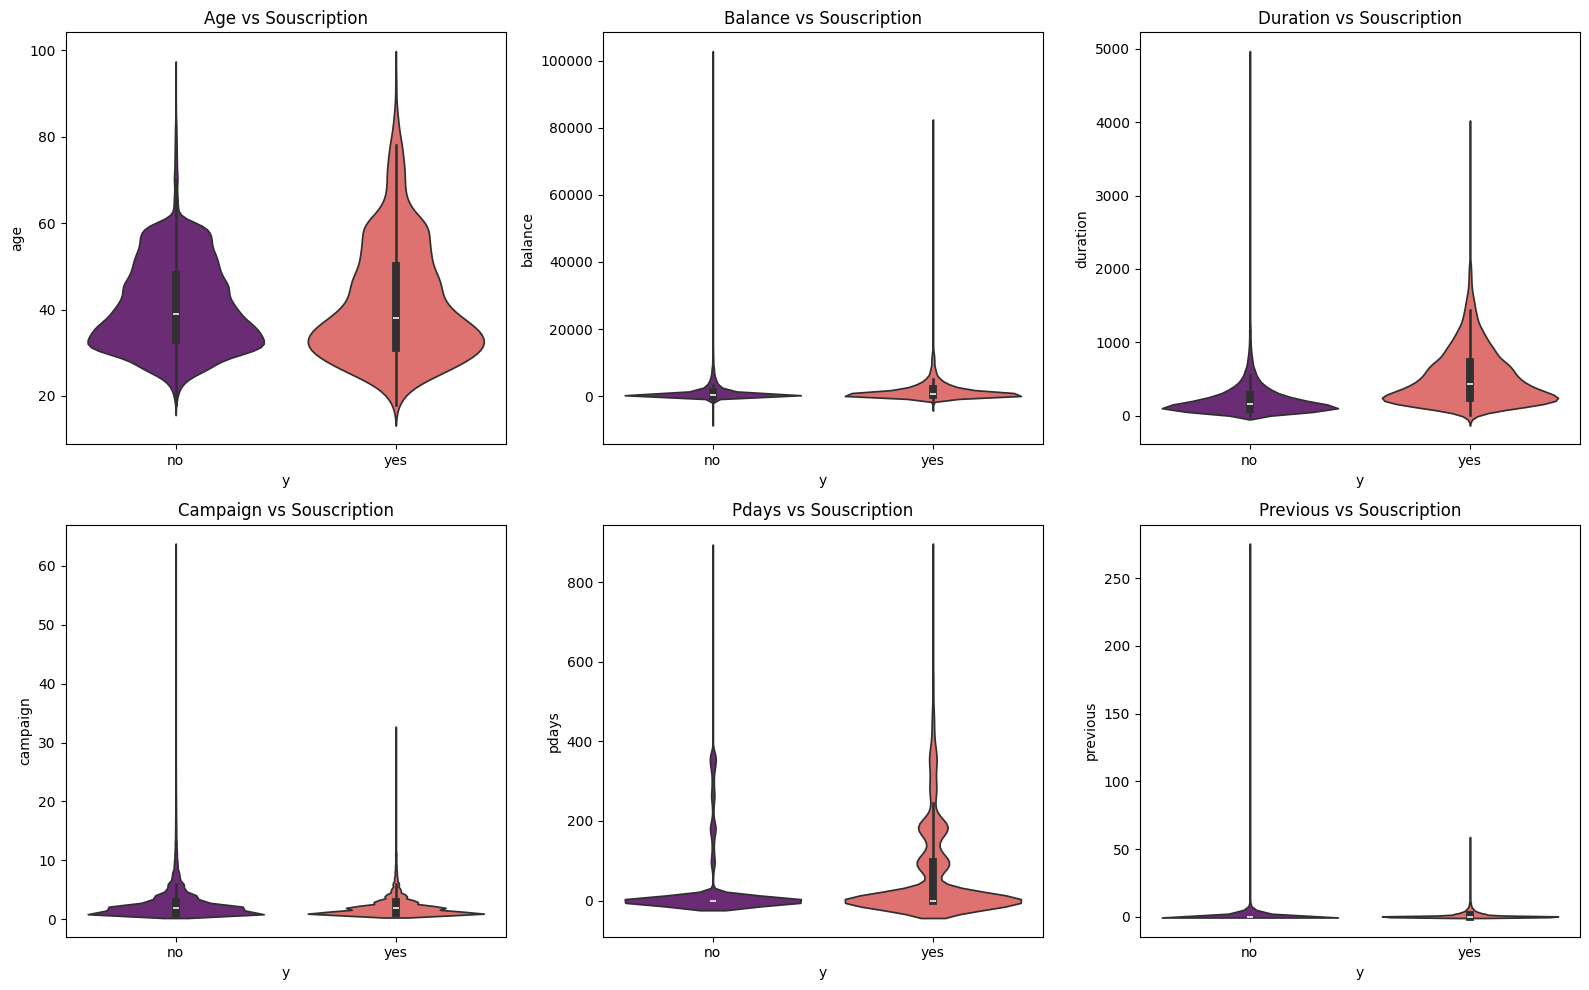

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

sns.violinplot(x="y", y="age", data=df, ax=axes[0,0], palette="magma", inner="box")
axes[0,0].set_title("Age vs Souscription")

sns.violinplot(x="y", y="balance", data=df, ax=axes[0,1], palette="magma")
axes[0,1].set_title("Balance vs Souscription")

sns.violinplot(x="y", y="duration", data=df, ax=axes[0,2], palette="magma")
axes[0,2].set_title("Duration vs Souscription")

sns.violinplot(x="y", y="campaign", data=df, ax=axes[1,0], palette="magma")
axes[1,0].set_title("Campaign vs Souscription")

sns.violinplot(x="y", y="pdays", data=df, ax=axes[1,1], palette="magma")
axes[1,1].set_title("Pdays vs Souscription")

sns.violinplot(x="y", y="previous", data=df, ax=axes[1,2], palette="magma")
axes[1,2].set_title("Previous vs Souscription")

plt.tight_layout()
plt.show()

Nous avions en premier lieu effectuer les boxplots que vous pouvez trouvez ci dessus mais au final nous sommes partis sur des violinplots car nous trouvons que cela ajoute une estimation de densité qui montre comment les données sont répartis. Nous voyons l'asymétrie, les pics et les trous comparés aux boxplots. Nous avons choisis de laisser les deux ici pour justifié notre choix.

**Age**
- médianes assez proches entre yes / no
- pas de différence très marquée
- peut-être légèrement plus de clients âgés dans yes ? mais pas très clair
 > à vérifier mais pas forcément une variable très discriminante

**Balance**
- clients yes semblent avoir un peu plus de balance en moyenne
- MAIS énormément d’outliers
- certaines valeurs très élevées (100k+)
 > difficile de conclure
 > possible que balance joue un rôle mais dispersion très forte
note : peut-être regarder la distribution plus tard

**Duration**
- là différence très visible
- les appels sont clairement beaucoup plus longs pour yes
 > logique : plus la conversation dure, plus le client peut être convaincu
 > variable très informative

> mais attention : duration est connue après l’appel, donc peut poser un problème pour la prédiction

**Campaign**
- la majorité des valeurs entre 1 et 3 contacts
- distributions assez similaires entre yes / no
 > pas de différence évidente
 > peut-être faible impact

**Pdays**
- beaucoup de valeurs à 0
- distribution un peu différente entre yes / no mais pas super lisible
- note : pdays = nb jours depuis dernier contact -> peut avoir un effet mais pas évident ici

**Previous**
- presque toutes les valeurs sont 0
- très peu de variation
 > variable probablement peu informative

**Notes générales**
- beaucoup d’outliers sur certaines variables (balance, pdays, previous)
- certaines variables ne semblent pas très discriminantes seules
- duration ressort clairement
  - idée :
     > regarder aussi les variables catégorielles (job, education, housing…)
     > peut-être qu’elles expliquent mieux la souscription

## Taux de souscription par variable catégorielle (crosstab)

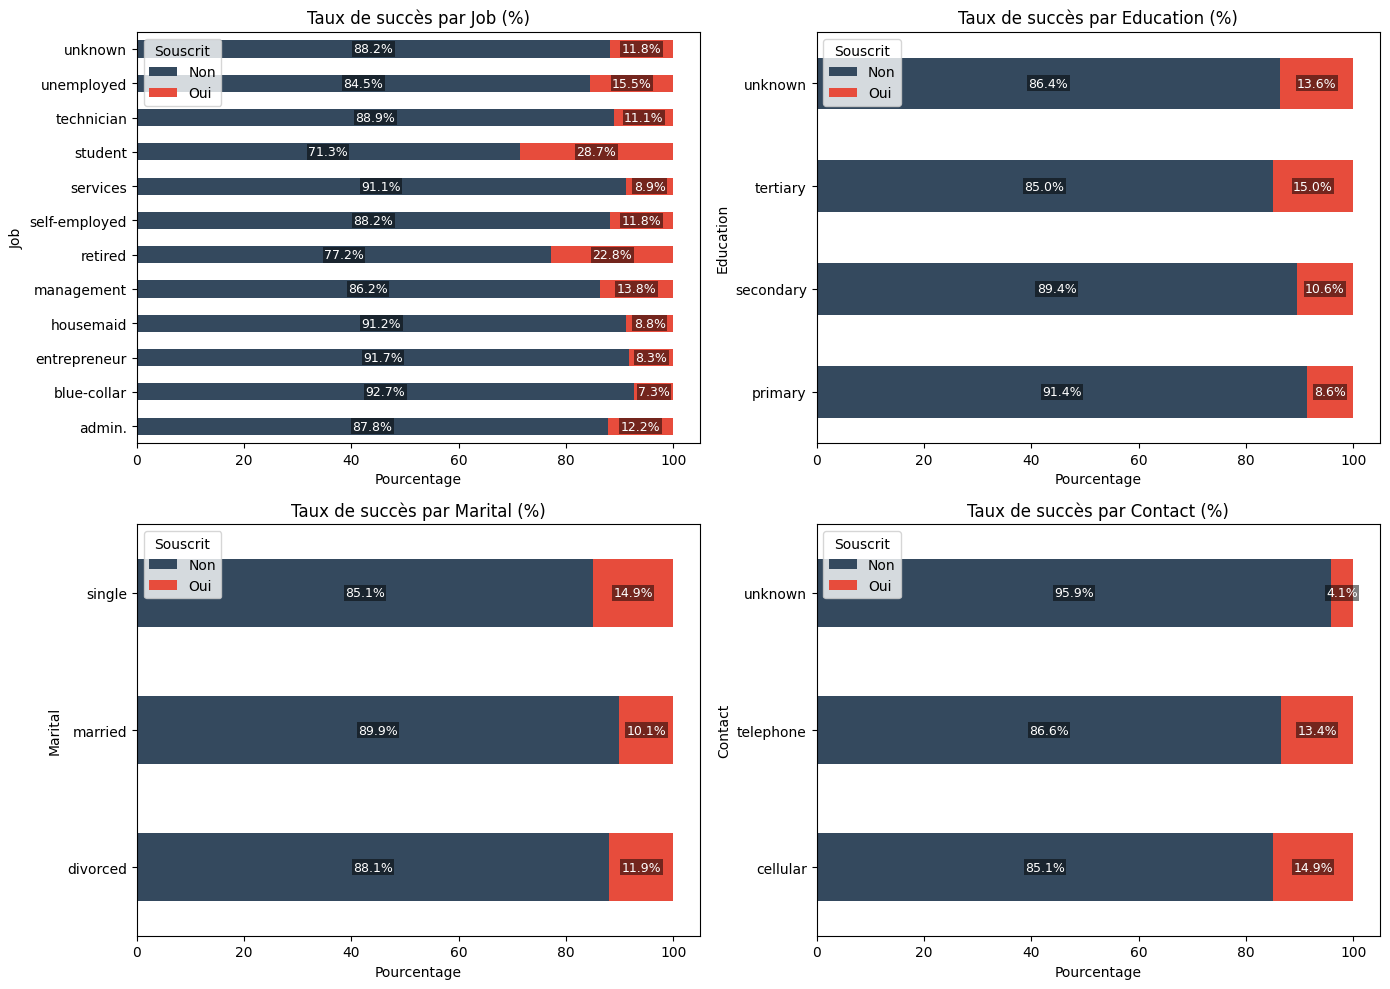

In [ ]:
categorical_cols_to_plot = ['job', 'education', 'marital', 'contact']

num_cols_per_row = 2
num_rows = (len(categorical_cols_to_plot) + num_cols_per_row - 1) // num_cols_per_row

fig, axes = plt.subplots(num_rows, num_cols_per_row, figsize=(14, 5 * num_rows))

axes = axes.flatten()

for i, col in enumerate(categorical_cols_to_plot):
    ct = pd.crosstab(df[col], df['y'], normalize='index') * 100

    ct.plot(kind='barh', stacked=True, ax=axes[i], color=['#34495e', '#e74c3c'])

    for container in axes[i].containers:
        for rect in container:
            width = rect.get_width()
            height = rect.get_height()
            x_pos = rect.get_x()
            y_pos = rect.get_y()

            if width > 0:
                axes[i].text(x_pos + width / 2,
                             y_pos + height / 2,
                             f'{width:.1f}%',
                             ha='center', va='center', color='white', fontsize=9,
                             bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', pad=1))

    axes[i].set_title(f'Taux de succès par {col.capitalize()} (%)')
    axes[i].set_xlabel('Pourcentage')
    axes[i].set_ylabel(col.capitalize())
    axes[i].legend(title='Souscrit', labels=['Non', 'Oui'], loc='best')


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


- Taux de succès par Job (%) : Les étudiants (28,7 %) et les retraités (22,8 %)
sont les deux catégories qui acceptent le plus l'offre, se détachant nettement des autres métiers.

- Taux de succès par Education (%) : Le taux de réussite progresse avec le niveau d'études, atteignant son maximum chez les profils de niveau supérieur (tertiary) avec 15,0 %.

- Taux de succès par Marital (%) : Les célibataires sont les plus réceptifs (14,9 %), devant les divorcés (11,9 %) et les personnes mariées (10,1 %).

- Taux de succès par Contact (%) : Le contact via téléphone portable est le plus efficace (14,9 %).**texte en gras**


## Analyse comparative des variables catégorielles

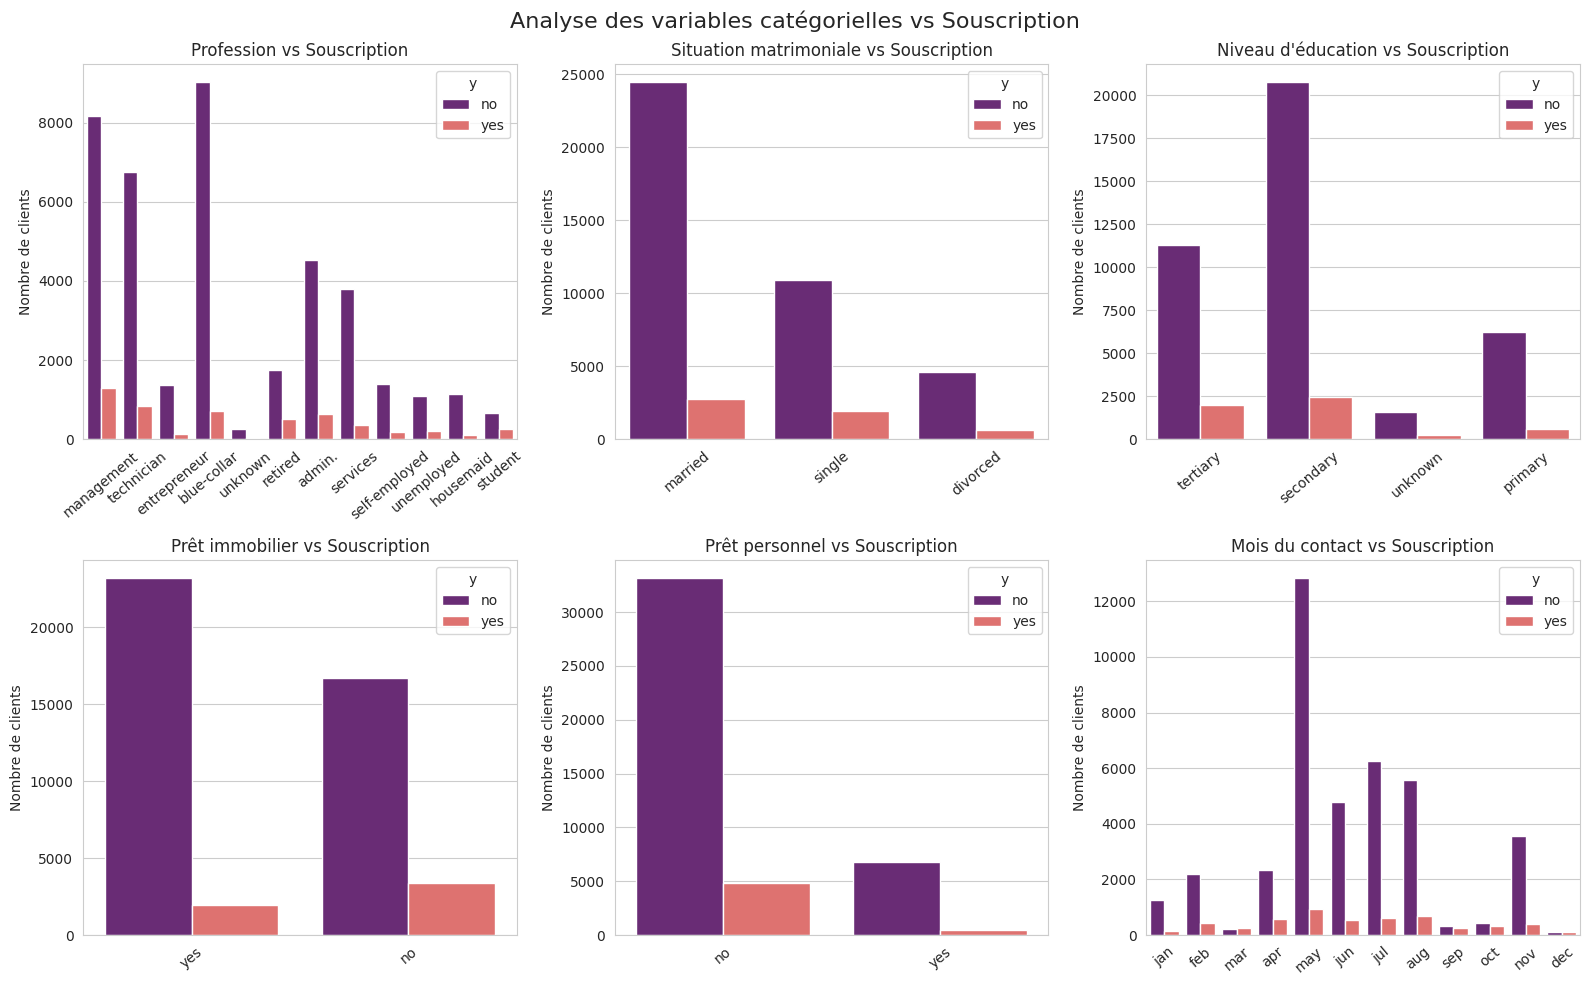

In [ ]:
sns.set_style("whitegrid")

fig, axes = plt.subplots(2, 3, figsize=(16,10))

palette = "magma"

variables = ["job","marital","education","housing","loan","month"]
titles = [
    "Profession vs Souscription",
    "Situation matrimoniale vs Souscription",
    "Niveau d'éducation vs Souscription",
    "Prêt immobilier vs Souscription",
    "Prêt personnel vs Souscription",
    "Mois du contact vs Souscription"
]

month_order = ["jan","feb","mar","apr","may","jun","jul","aug","sep","oct","nov","dec"]

for ax, var, title in zip(axes.flatten(), variables, titles):

    if var == "month":
        sns.countplot(x=var, hue="y", data=df, order=month_order, palette=palette, ax=ax)
    else:
        sns.countplot(x=var, hue="y", data=df, palette=palette, ax=ax)

    ax.set_title(title, fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("Nombre de clients")
    ax.tick_params(axis="x", rotation=40)

fig.suptitle("Analyse des variables catégorielles vs Souscription", fontsize=16)

plt.tight_layout()
plt.show()

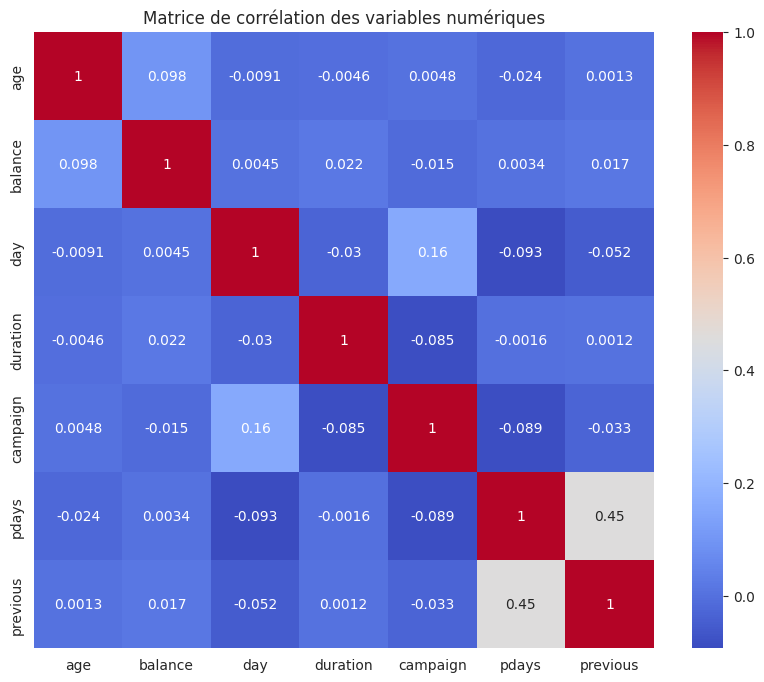

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Matrice de corrélation des variables numériques")

plt.show()

# **3. Préparation des données**


## Nettoyage / transformation

In [ ]:
client_features = ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan']

df_sorted = df.sort_values(by=client_features + ['previous', 'campaign'],
                           ascending=[True]*len(client_features) + [True, True])

df_unique = df_sorted.drop_duplicates(subset=client_features, keep='last')

print(f"Lignes avant : {len(df)}")
print(f"Lignes après (Nettoyage Chronologique) : {len(df_unique)}")
print(f"Nombre de parcours clients simplifiés : {len(df) - len(df_unique)}")


Lignes avant : 45211
Lignes après (Nettoyage Chronologique) : 41048
Nombre de parcours clients simplifiés : 4163


L'analyse exploratoire a révélé que certains clients apparaissent plusieurs fois dans le dataset, correspondant à des suivis marketing successifs. Afin d'éviter un biais de répétition dans le clustering (où un client multi-contacté pèserait plus lourd qu'un autre), nous avons mis en place une stratégie de consolidation :

- Identification unique : Faute d'identifiant client, nous avons généré une empreinte digitale combinant les variables fixes (âge, métier, éducation) et les variables de situation financière (solde, prêts en cours).

- Logique de sélection : Pour chaque client identifié, nous avons conservé uniquement l'enregistrement le plus récent (en se basant sur les compteurs campaign et previous).

In [ ]:
# Copie de travail
df_clean = df_unique.copy()

In [ ]:
# Vérification des doublons
print("Doublons complets :", df_clean.duplicated().sum())

Doublons complets : 0


In [ ]:
# check des unknowns

cat_cols = ["job", "marital", "education", "default", "housing",
            "loan", "contact", "month", "poutcome"]

(df[cat_cols] == "unknown").sum()

,0
job,288
marital,0
education,1857
default,0
housing,0
loan,0
contact,13020
month,0
poutcome,36959


In [ ]:
# un peu de feature engineering sur pdays (jours) pour traiter correctement le cas -1 (jamais été contacté avant)

df_clean["pdays_never_contacted"] = (df_clean["pdays"] == -1).astype(int)
# 1 = client jamais contacté auparavant / 0 = client déjà contacté auparavant

df_clean["pdays_clean"] = df_clean["pdays"].replace(-1, np.nan)
# -1 est remplacé par NaN


Pour pdays, une variable indicatrice (pdays_never_contacted) et une variable numérique nettoyée (pdays_clean) sont créées afin de distinguer clairement le cas “jamais contacté” de l’information temporelle réelle.

### Deux versions du dataset :
1. version pré-appel : sans duration
2. version post-appel : avec duration

In [ ]:
df_pre_call = df_clean.drop(columns=["duration"])
df_post_call = df_clean.copy()

print("Shape pre-call :", df_pre_call.shape)
print("Shape post-call:", df_post_call.shape)

Shape pre-call : (41048, 18)
Shape post-call: (41048, 19)


Pourquoi ?

La variable duration correspond à la durée de l’appel et n’est connue qu’après le contact avec le client. Elle sera donc exclue du modèle pré-appel afin d’éviter une fuite d’information.

-> duration n’est pas disponible au moment où la banque décide d’appeler ou non.

Donc :

Notre objectif étant de : 'prédire quels clients contacter pour optimiser les coûts.' on ne peux pas utiliser la durée de l’appel, puisque cette information n’existe qu’après que l’appel a eu lieu.

En gros :

Duration peut expliquer le succès d’un appel, mais elle ne peut pas servir à décider à l’avance qui appeler.

### Outliers avec la règle IQR

On calcule :

Q1 = 1er quartile
Q3 = 3e quartile
IQR = Q3 - Q1
Puis on définit deux bornes :

borne basse = Q1 - 1.5 * IQR
borne haute = Q3 + 1.5 * IQR
Toute valeur :

plus petite que la borne basse
ou plus grande que la borne haute

In [ ]:
numeric_cols = ["age", "balance", "day", "duration", "campaign", "pdays", "previous"]

for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    pct = round(outliers / len(df) * 100, 2)

    print(f"{col} : {outliers} outliers ({pct}%)")

age : 487 outliers (1.08%)
balance : 4729 outliers (10.46%)
day : 0 outliers (0.0%)
duration : 3235 outliers (7.16%)
campaign : 3064 outliers (6.78%)
pdays : 8257 outliers (18.26%)
previous : 8257 outliers (18.26%)


On a pu voir que il y a clairement des outliers, surtout sur balance, duration, campaign, pdays, previous.

Mais la bonne question est -> peut-on justifier de les garder pour le modeling ?

### Conclusion

À ce stade, les valeurs 'unknown' sont conservées comme catégories informatives. La variable 'pdays = -1', correspondant au cas “jamais contacté”, est traitée séparément à l’aide d’une variable indicatrice et d’une version numérique nettoyée. Enfin, la variable 'duration', connue uniquement après l’appel, sera exclue du modèle pré-appel afin d’éviter une fuite d’information.


###Transformation

In [ ]:
def month_to_season(month):
    # On met en minuscule pour éviter les erreurs de casse
    month = str(month).lower()
    if month in ['mar', 'apr', 'may']:
        return 'printemps'
    elif month in ['jun', 'jul', 'aug']:
        return 'été'
    elif month in ['sep', 'oct', 'nov']:
        return 'automne'
    elif month in ['dec', 'jan', 'feb']:
        return 'hiver'
    else:
        return 'inconnu'

df_pre_call['season'] = df_pre_call['month'].apply(month_to_season)


In [ ]:
df_pre_call = pd.get_dummies(df_pre_call, columns=['season'], prefix='season')

df_pre_call = df_pre_call.drop(columns=['month'])

print(df_pre_call.filter(like='season').head())

       season_automne  season_hiver  season_printemps  season_été
42274            True         False             False       False
40736           False         False             False        True
41252           False         False             False        True
42146            True         False             False       False
41273           False         False             False        True


In [ ]:
edu_mapping = {"primary": 1, "secondary": 2, "tertiary": 3, "unknown": 0}
df_pre_call['education'] = df_pre_call['education'].map(edu_mapping)

In [ ]:
transformer = ColumnTransformer([
    ('marital_ohe', OneHotEncoder(), ['marital']),
    ('contact_ohe', OneHotEncoder(), ['contact']),
    ('poutcome_ohe', OneHotEncoder(), ['poutcome']),
    ('job_ohe', OneHotEncoder(), ['job']),
    ('num_std', StandardScaler(), ['age', 'balance', 'education', 'day', 'campaign', 'previous', 'pdays'])
], remainder='passthrough')

In [ ]:
le = LabelEncoder()
df_pre_call['y'] = le.fit_transform(df_pre_call['y'])
df_pre_call['housing'] = le.fit_transform(df_pre_call['housing'])
df_pre_call['default'] = le.fit_transform(df_pre_call['default'])
df_pre_call['loan'] = le.fit_transform(df_pre_call['loan'])

1. Pourquoi l'Ordinal Encoding pour education ?

    Cette technique a été choisie car il existe une hiérarchie logique entre les niveaux d'études.

- Conservation de l'ordre : Les analyses précédentes ont montré que le taux de succès augmente avec le niveau d'instruction, passant de 8,6 % pour le niveau primaire à 15,0 % pour le niveau supérieur.

- Signal mathématique : En attribuant des valeurs croissantes (0, 1, 2, 3), le modèle peut interpréter mathématiquement que plus le niveau est élevé, plus la probabilité de souscription est forte.

2. Pourquoi le One-Hot Encoding pour marital, contact et job ?
- Cette méthode est utilisée pour les variables nominales, c'est-à-dire les catégories sans ordre d'importance ou de supériorité entre elles.

- Neutralité mathématique : Contrairement à l'encodage ordinal, le One-Hot Encoding évite de créer une fausse hiérarchie. Par exemple, il empêche le modèle de considérer qu'être "marié" est mathématiquement "supérieur" à être "célibataire".

- Isolation des segments : Cela permet au modèle de détecter l'impact spécifique de chaque groupe, comme le taux de succès élevé des étudiants (28,7 %) ou l'efficacité des contacts par mobile (14,9 %).

3. Pourquoi le LabelEncoder pour la cible y ?
- Nécessité algorithmique : Les modèles de Machine Learning ne peuvent pas effectuer de calculs sur des étiquettes textuelles ("yes"/"no").

- Conversion binaire : Transformer la cible en 0 (échec) et 1 (succès) est la condition nécessaire pour définir une fonction de coût et permettre au modèle d'apprendre à prédire le résultat.

4. Pourquoi le StandardScaler pour age, balance et duration ?
- La standardisation est indispensable car les variables numériques présentent des échelles totalement différentes.

- Équilibre des poids : Sans cette étape, une variable avec des valeurs élevées comme le solde (balance), qui peut dépasser 100 000, écraserait totalement une variable comme l'âge (maximum 95) lors des calculs de distance ou de gradient.

- Robustesse face aux valeurs extrêmes : Des "outliers" (valeurs aberrantes) ont été identifiés dans le solde et la durée des appels. Le StandardScaler (basé sur le Z-score) est plus adapté que la normalisation Min-Max dans ce cas, car il ne compresse pas l'ensemble des données dans un intervalle minuscule à cause d'une seule valeur géante.


In [ ]:
df_final = pd.DataFrame(
    transformer.fit_transform(df_pre_call),
    columns=transformer.get_feature_names_out()
)

In [ ]:
protected_cols = ['pdays_never_contacted', 'poutcome_success', 'poutcome_failure', 'poutcome_other', 'poutcome_unknown']
df_final.columns = [col.split('__')[-1] for col in df_final.columns]
df_final.columns = [col.split('_')[-1] if col not in protected_cols else col for col in df_final.columns]

In [ ]:
df_final = df_final.drop('clean', axis=1)

### Séparation de la cible et des caractéristiques:

In [ ]:
X = df_final.drop(columns=['y'])
y = df_final['y']

### Train Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

La division en Train et Test permet d'entraîner le modèle sur une partie des données et de l'évaluer sur une autre. Cela garantit que le modèle est capable de généraliser ses prédictions à de nouveaux clients sans faire de surapprentissage.

### SMOTE

In [ ]:
print(f"Distribution avant SMOTE : {Counter(y_train)}")

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train.astype(int))

X_train = X_train.astype(float)
y_train = y_train.astype(int)

print(f"Distribution après SMOTE : {Counter(y_train)}")

Distribution avant SMOTE : Counter({0: 29372, 1: 3466})
Distribution après SMOTE : Counter({0: 29372, 1: 29372})


Le dataset présente un déséquilibre de classe significatif (classe minoritaire 'yes' sous-représentée), ce qui peut biaiser les prédictions du modèle en faveur de la majorité. Pour y remédier, nous avons implémenté la technique SMOTE (Synthetic Minority Over-sampling Technique). Contrairement à un simple sur-échantillonnage aléatoire, le SMOTE génère des exemples synthétiques en interpolant entre les voisins proches de la classe minoritaire, permettant ainsi au modèle de mieux généraliser les caractéristiques des clients ayant souscrit à l'offre.

# **4. Machine Learning**


## **A- Modèle de régression logistique**





La régression logistique est un modèle statistique de classification utilisé pour prédire la probabilité qu’une observation appartienne à une catégorie binaire (0/1, oui/non).


Elle repose sur une combinaison linéaire des variables explicatives, transformée par une fonction logistique (sigmoïde) afin de produire une probabilité comprise entre 0 et 1.

In [ ]:
print(y_train.head())
print(y_train.dtype)
print(y_train.unique())

0    0
1    0
2    0
3    0
4    0
Name: y, dtype: int64
int64
[0 1]


On voit que :
- Les valeurs sont bien 0 et 1
- Mais le type est encore object

### Convertir "y" en entier

In [ ]:
y_train = y_train.astype(int)
y_test = y_test.astype(int)

print(y_train.dtype)
print(y_test.dtype)

int64
int64


In [ ]:
# vérifier que X_train est numérique
print(X_train.dtypes.value_counts())

float64    37
Name: count, dtype: int64


### Entraîner le modèle de régression logistique

- 1 = le client souscrit
- 0 = le client ne souscrit pas

In [ ]:
log_reg = LogisticRegression(
    max_iter=1000, # nombre maximum d’itérations autorisées / ajuste les coefficients(par défaut)
    random_state=42 # rendre les résultats reproductibles
)

log_reg.fit(X_train, y_train)

print("Modèle OK")

Modèle OK


Le dataset bancaire est déséquilibré :
- Beaucoup de 0
- Peu de 1

Si on ne fait rien :
- Le modèle va privilégier la classe majoritaire
- Il pourrait prédire presque toujours 0

balanced : Le modèle ajuste automatiquement les poids

Pourquoi 42 ?
- Aucune raison scientifique
- C’est une convention en data science.

### Prédictions

Pour chaque client du jeu de test, est-ce qu’il souscrit (1) ou non (0) ?

- y_pred → Calcule une probabilité -> Compare à un seuil (0,5) -> Transforme en classe (si probabilité ≥ 0.5 → 1 / sinon → 0)
- y_prob → probabilités entre 0 et 100 -> pas la classe (permetd’ajuster le seuil, faire une courbe ROC, faire une courbe ROC, etc)

In [ ]:
y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:, 1]

print(y_pred[:10])
print(y_prob[:10])

[0 0 0 0 1 0 0 0 0 0]
[0.23485047 0.27327748 0.23010918 0.33317308 0.5722084  0.30422329
 0.38572368 0.42774386 0.48118322 0.47899002]


Interprétation :

- Client 1 → 23.5% de chance de souscrire
- Client 7 → 39%
- Client 8 → 43%

### Évaluer le modèle

Métriques:

- Precision : Parmi les clients que le modèle dit "oui", combien sont vraiment "oui" ?
- Recall : Parmi les vrais clients qui ont souscrit, combien le modèle a réussi à détecter ?
- F1 score : moyenne harmonique entre Precision et Recall -> F1 équilibre les deux.
- Support : Le nombre d’exemples réels dans chaque classe.
- Accuracy : Pourcentage total de bonnes prédictions.
- Macro average : C’est la moyenne simple des scores des classes.
- Weighted average : C’est une moyenne pondérée par le nombre d’exemples.

In [ ]:
print(classification_report(y_test, y_pred))
print("ROC-AUC :", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.94      0.71      0.81      7344
           1       0.20      0.64      0.31       866

    accuracy                           0.70      8210
   macro avg       0.57      0.67      0.56      8210
weighted avg       0.86      0.70      0.76      8210

ROC-AUC : 0.7335819848853065


- Precision :
Détection des 0 → très bon
Détection des 1 → pas bon (20% donc beaucoup de faux positifs)

- Recall :    
Détection des 0 → correct (71%)
Détection des 1 → correct mais imparfait (64% donc 36% de raté)

- Accuracy : 70% -> correct

- Macro avg (La moyenne simple entre classe 0 et 1) : 0,56

- ROC-AUC : 0,73 -> correct

Un choix se pose:

- Rater un client qui aurait souscrit ?

ou

- Appeler un client qui finalement ne souscrit pas ? -> notre choix


Donc nouveau seuil -> 0.3

In [ ]:
threshold = 0.3

y_pred_03 = (y_prob >= threshold).astype(int)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_03))

              precision    recall  f1-score   support

           0       0.96      0.31      0.47      7344
           1       0.13      0.89      0.23       866

    accuracy                           0.37      8210
   macro avg       0.55      0.60      0.35      8210
weighted avg       0.87      0.37      0.44      8210



Nous avons comparé deux seuils de décision : 0.5 (seuil standard) et 0.3.

Avec un seuil à 0.5, le modèle est globalement plus équilibré.
- L’accuracy est correcte (37%) et la performance moyenne (F1 macro = 0,56) reste acceptable.
- Mais, le modèle ne détecte que 64% des clients qui souscrivent, ce qui signifie que 36% des souscripteurs sont ratés.

Avec un seuil à 0.3, ça change.
- Le modèle détecte 89% des clients qui souscrivent, ce qui réduit fortement le risque de rater une opportunité commerciale.
- MAIS, la précision sur la classe 1 chute (13%), ce qui signifie que l’on appelle beaucoup de clients qui ne souscriront finalement pas. L’accuracy globale baisse à 37%, car le modèle prédit beaucoup plus de positifs.

En conclusion:
Le choix dépend donc de l’objectif métier :
- Si l’on cherche un modèle équilibré -> seuil 0.5
- Si l’on préfère éviter de rater des clients potentiellement intéressés -> seuil 0.3

Dans une logique commerciale, où rater un souscripteur coûte plus cher qu’un appel inutile, le seuil à 0.3 peut être justifié.


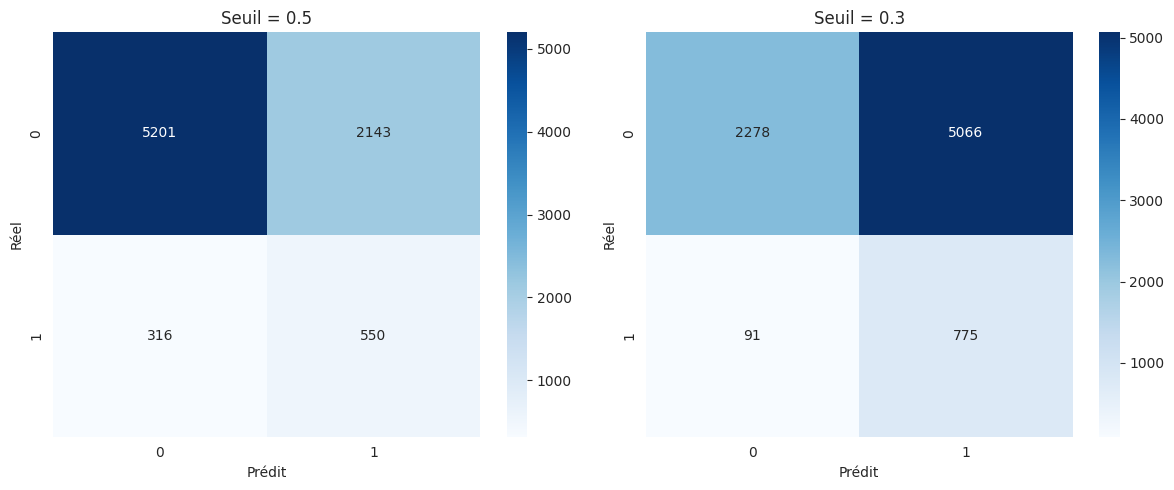

In [ ]:
# Seuil 0.5
y_pred_05 = (y_prob >= 0.5).astype(int)

# Seuil 0.3
y_pred_03 = (y_prob >= 0.3).astype(int)

cm_05 = confusion_matrix(y_test, y_pred_05)
cm_03 = confusion_matrix(y_test, y_pred_03)

fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.heatmap(cm_05, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Seuil = 0.5")
axes[0].set_xlabel("Prédit")
axes[0].set_ylabel("Réel")

sns.heatmap(cm_03, annot=True, fmt="d", cmap="Blues", ax=axes[1])
axes[1].set_title("Seuil = 0.3")
axes[1].set_xlabel("Prédit")
axes[1].set_ylabel("Réel")

plt.tight_layout()
plt.show()

- Avec un seuil à 0.5, le modèle est plus équilibré : il détecte correctement une partie des souscripteurs (550) mais en rate encore 316.
Le nombre de faux positifs reste important (2 101), mais maîtrisé.
- Avec un seuil à 0.3, le modèle détecte davantage de souscripteurs (775) et réduit fortement les clients ratés (91 seulement).
MAIS, les faux positifs augmentent fortement (5 066), ce qui entraîne beaucoup d’appels inutiles.


En résumé, 0.5 = équilibre, 0.3 = priorité à la détection des souscripteurs, avec un coût opérationnel plus élevé.

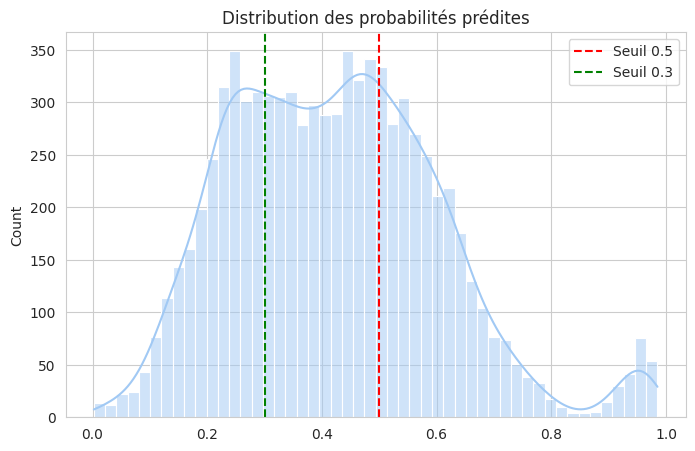

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(y_prob, bins=50, kde=True)

plt.axvline(0.5, color='red', linestyle='--', label='Seuil 0.5')
plt.axvline(0.3, color='green', linestyle='--', label='Seuil 0.3')

plt.title("Distribution des probabilités prédites")
plt.legend()
plt.show()

- La distribution des probabilités montre que la majorité des prédictions se situent entre 0.2 et 0.6, avec un pic autour de 0.4–0.5.
Le modèle n’est donc pas extrêmement tranché : beaucoup d’observations ont des probabilités intermédiaires.
- Avec un seuil à 0.5, seule la partie la plus à droite de la distribution est classée en 1.
On adopte une décision plus prudente : seuls les profils les plus susceptibles sont considérés comme souscripteurs.
- Avec un seuil à 0.3, une grande partie des probabilités intermédiaires bascule en classe 1.
Cela explique l’augmentation du recall (on détecte davantage de souscripteurs), mais aussi la forte hausse des faux positifs.

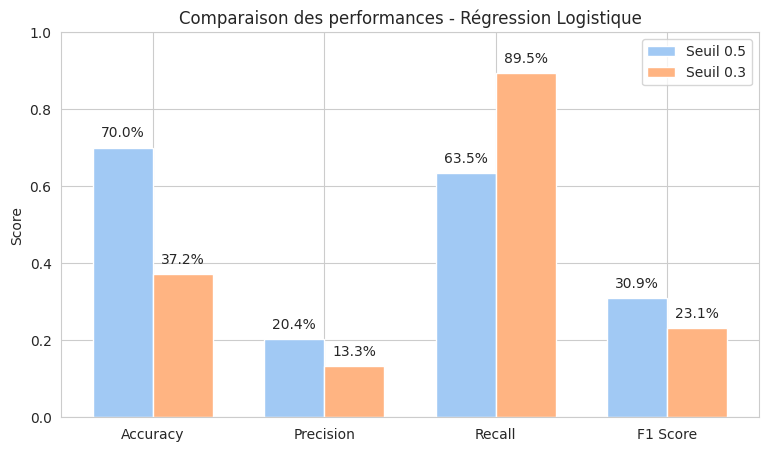

In [ ]:
# Seuil 0.5
y_pred_05 = (y_prob >= 0.5).astype(int)

accuracy_05 = accuracy_score(y_test, y_pred_05)
precision_05 = precision_score(y_test, y_pred_05)
recall_05 = recall_score(y_test, y_pred_05)
f1_05 = f1_score(y_test, y_pred_05)

# Seuil 0.3
y_pred_03 = (y_prob >= 0.3).astype(int)

accuracy_03 = accuracy_score(y_test, y_pred_03)
precision_03 = precision_score(y_test, y_pred_03)
recall_03 = recall_score(y_test, y_pred_03)
f1_03 = f1_score(y_test, y_pred_03)

# Graphique comparatif
labels = ["Accuracy", "Precision", "Recall", "F1 Score"]

scores_05 = [accuracy_05, precision_05, recall_05, f1_05]
scores_03 = [accuracy_03, precision_03, recall_03, f1_03]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9,5))

bars1 = ax.bar(x - width/2, scores_05, width, label="Seuil 0.5")
bars2 = ax.bar(x + width/2, scores_03, width, label="Seuil 0.3")

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0,1)
ax.set_ylabel("Score")
ax.set_title("Comparaison des performances - Régression Logistique")
ax.legend()

# Ajout des pourcentages
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.02,
            f"{height*100:.1f}%",
            ha='center',
            va='bottom'
        )

add_labels(bars1)
add_labels(bars2)

plt.show()

### Conclusion

La régression logistique permet de prédire la probabilité de souscription avec une performance satisfaisante (ROC-AUC ≈ 0,73), traduisant une bonne capacité de discrimination entre souscripteurs et non-souscripteurs.

L’analyse des seuils montre que le modèle est sensible au choix de la décision finale. Avec un seuil à 0.5, les performances restent équilibrées et le nombre d’appels inutiles est limité. En abaissant le seuil à 0.3, le modèle détecte une très grande majorité des souscripteurs (fort recall), mais au prix d’une forte augmentation des faux positifs, ce qui génère davantage d’appels non rentables.

Le choix du seuil doit donc être aligné avec l’objectif métier : rechercher un compromis global ou privilégier la détection maximale des opportunités commerciales.

## **B- K Nearest Neighbors (KNN)**

Dans cette partie, nous appliquons l’algorithme **K-Nearest Neighbors (KNN)** afin de prédire si un client souscrira ou non au produit bancaire.

KNN est un modèle de **classification supervisée** qui attribue à une nouvelle observation la classe majoritaire parmi ses **K voisins les plus proches**.

Ce modèle est pertinent ici car la variable cible `y` est **binaire** (`yes/no`). Il permet de comparer un client à des clients similaires déjà observés.

Nous utilisons la version **pré-appel** du dataset (`df_pre_call`), c’est-à-dire sans la variable `duration`, afin d’éviter une **fuite de données (data leakage)**.

### **Tester plusieurs valeurs de K**

Afin de déterminer la valeur optimale du paramètre K pour le modèle KNN, plusieurs modèles seront entraînés avec des valeurs de K allant de 1 à 20. La performance de chaque modèle sera évaluée à l’aide du **F1-score**, qui est particulièrement adapté dans notre contexte de déséquilibre de classes.

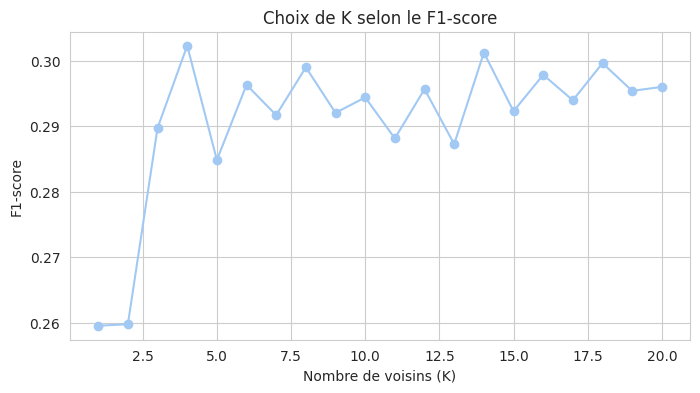

In [ ]:
k_values = range(1, 21)
f1_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    f1 = f1_score(y_test, y_pred)
    f1_scores.append(f1)

plt.figure(figsize=(8,4))
plt.plot(k_values, f1_scores, marker='o')
plt.title("Choix de K selon le F1-score")
plt.xlabel("Nombre de voisins (K)")
plt.ylabel("F1-score")
plt.show()

**Choix du meilleur K**

Le graphique ci-dessus montre l’évolution du F1-score en fonction de K. On observe que la meilleure performance est obtenue pour **K = 4**, avec un F1-score d’environ **0.31**.

Cette valeur a donc été retenue pour entraîner le modèle KNN final.

### **Entraîner le modèle final KNN**

On entraîne le modèle KNN avec le meilleur nombre de voisins.

In [ ]:
knn_best = KNeighborsClassifier(n_neighbors=4)
knn_best.fit(X_train_scaled, y_train)

y_pred_knn = knn_best.predict(X_test_scaled)
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.92      0.87      0.90      7344
           1       0.26      0.37      0.30       866

    accuracy                           0.82      8210
   macro avg       0.59      0.62      0.60      8210
weighted avg       0.85      0.82      0.83      8210



Le modèle final KNN est prêt à être évalué.

### **Évaluer le KNN**

              precision    recall  f1-score   support

           0       0.92      0.87      0.90      7344
           1       0.26      0.37      0.30       866

    accuracy                           0.82      8210
   macro avg       0.59      0.62      0.60      8210
weighted avg       0.85      0.82      0.83      8210



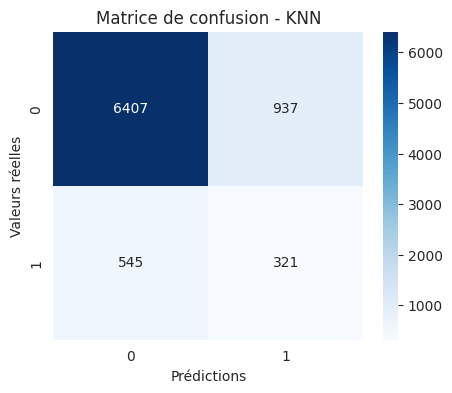

In [ ]:
print(classification_report(y_test, y_pred_knn))

cm = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matrice de confusion - KNN")
plt.xlabel("Prédictions")
plt.ylabel("Valeurs réelles")
plt.show()

Le classification_report donne :**précision**, **recall** et **F1-score**.

Le KNN est évalué avec des métriques cohérentes avec le problème métier.
Comme les classes sont déséquilibrées, il faut aller au-delà de l’accuracy.

Le modèle a du mal à détecter les clients intéressés.On le voit avec :
precision classe 1 = 0.23
recall classe 1 = 0.47
f1-score = 0.31

La matrice de confusion montre :
- vrais négatifs 5943
- faux positifs 1401
- faux négatifs 455
- vrais positifs 411


***Interprétation de la matrice de confusion***

La matrice de confusion montre que le modèle identifie correctement une grande partie des clients qui ne souscrivent pas (5943 vrais négatifs). Il détecte également 411 clients réellement intéressés (vrais positifs).

Cependant, le modèle génère 1401 faux positifs, c’est-à-dire des clients prédits comme intéressés alors qu’ils ne le sont pas. Il manque également 455 clients qui auraient souscrit.

Ces résultats montrent que le modèle reste limité pour détecter la classe positive, ce qui est cohérent avec le déséquilibre important des classes dans ce dataset.

### **Analyse ROC + AUC**

La **courbe ROC (Receiver Operating Characteristic)** permet d’évaluer la capacité du modèle à distinguer les deux classes : les clients qui souscrivent au produit bancaire et ceux qui ne souscrivent pas.

- 0 = client ne souscrit pas (Faux positifs, X)
- 1 = client souscrit (Vrais positifs, Y)

C’est une courbe qui montre la capacité du modèle à séparer les deux classes,

L'**AUC (Area Under Curve)** C’est l’aire sous la courbe ROC.
Une valeur d’AUC proche de **0.5** correspondrait à un modèle aléatoire, tandis qu’une valeur proche de **1** indiquerait une excellente capacité de discrimination.

Formule :
- Taux de vrai positif (recall) TPR = TP / (TP + FN). Cela mesure combien de clients intéressés sont détectés.
- Taux de faux positif FPR = FP / (FP + TN). Cela mesure combien de clients non intéressés sont incorrectement ciblés.

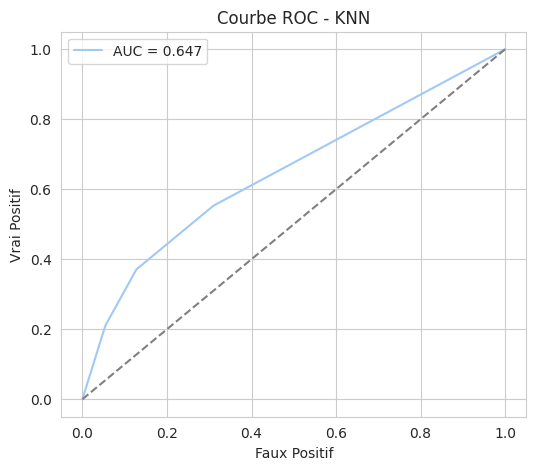

In [ ]:
# Probabilité que le client souscrive
y_prob = knn_best.predict_proba(X_test_scaled)[:,1]

# Calcul ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calcul AUC
auc_score = roc_auc_score(y_test, y_prob)

# Graph
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], linestyle='--', color='grey')

plt.xlabel("Faux Positif")
plt.ylabel("Vrai Positif")
plt.title("Courbe ROC - KNN")
plt.legend()
plt.show()

**Interprétation de la courbe ROC et de l'AUC**

La courbe ROC représente la relation entre le **taux de vrais positifs (True Positive Rate ou Recall)** et le **taux de faux positifs (False Positive Rate)** pour différents seuils de décision.

Dans notre cas, l’aire sous la courbe ROC (AUC) est de **0.683**. Cela signifie que le modèle possède une capacité **modérée** à différencier les clients susceptibles de souscrire de ceux qui ne souscrivent pas.

Avec une AUC de 0.683 le modèle KNN fait donc **mieux qu’un modèle aléatoire**, mais reste perfectible.

Ce résultat est cohérent avec la difficulté du problème et le **déséquilibre important des classes** dans le dataset. Malgré ces limites, le modèle est capable d’identifier une partie des clients susceptibles de souscrire, ce qui peut aider la banque à cibler plus efficacement ses campagnes marketing.

La courbe ROC confirme que le modèle possède une capacité de discrimination supérieure au hasard, mais elle suggère également qu’il pourrait être amélioré avec des modèles plus complexes comme Random Forest ou XGBoost.

## **C- XGBoost**

In [ ]:
# param_grid = {
#     "n_estimators": [100, 200],
#     "max_depth": [3, 4, 5],
#     "learning_rate": [0.05, 0.1],
#     "subsample": [0.8, 1],
#     "colsample_bytree": [0.8, 1]
# }

# xgb = XGBClassifier(
#     random_state=42,
#     eval_metric="logloss"
# )

# grid_search = GridSearchCV(
#     estimator=xgb,
#     param_grid=param_grid,
#     scoring="f1",
#     cv=3,
#     verbose=1,
#     n_jobs=-1
# )

# grid_search.fit(X_train_resampled, y_train_resampled)

# best_model = grid_search.best_estimator_

# print("Best parameters :", grid_search.best_params_)

# Fitting 3 folds for each of 48 candidates, totalling 144 fits
# Best parameters : {'colsample_bytree': 1, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}

On a réalisé un GridSearchCV pour optimiser les hyperparamètres du modèle (profondeur des arbres, learning rate, etc.). Il est commenté car il tourne facilement 3/4 min, mais les meilleurs paramètres trouvés ont bien été reportés dans le modèle ci-dessous.


In [ ]:
#lancement du modele

model = XGBClassifier(
    colsample_bytree=1,
    subsample=0.8,
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train.values, y_train.values)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None, colsample_bytree=1,
              device=None, early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred = model.predict(X_test.values)

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.98      0.95      7344
           1       0.56      0.23      0.32       866

    accuracy                           0.90      8210
   macro avg       0.74      0.60      0.63      8210
weighted avg       0.88      0.90      0.88      8210



L'accuracy de 91% paraît bonne mais elle est trompeuse vu le déséquilibre des classes. Le modèle prédit très bien les non-souscripteurs mais moins bon sur la classe 1, seulement 23% des vrais souscripteurs sont détectés. Cela dit, dans un dataset où la classe positive représente moins de 11% des observations, obtenir une précision de 56% sur cette classe reste un résultat solide.


<Axes: >

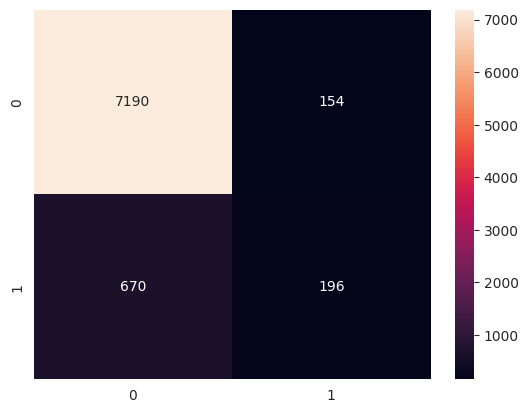

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d")

On voit clairement le problème : 670 faux négatifs, soit des souscripteurs que le modèle a ratés. Mais à l'inverse, seulement 154 faux positifs. le modèle est assez fiable quand il prédit une souscription, ce qui est utile en pratique pour cibler une campagne sans trop de bruit.


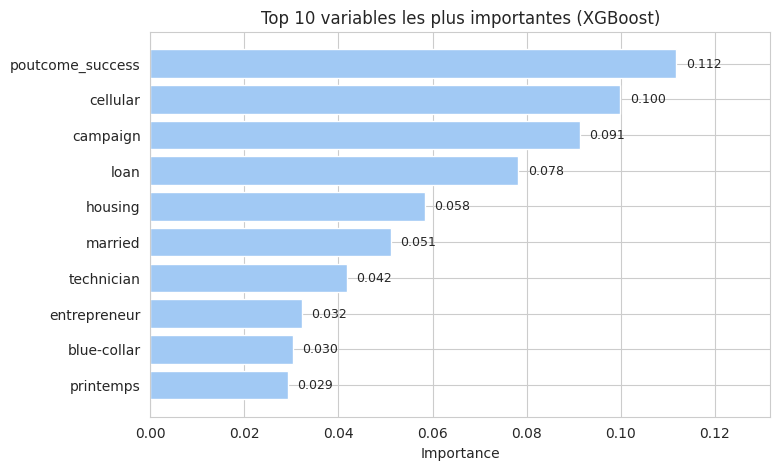

In [ ]:
feature_names = X.columns
importance_data = model.feature_importances_

importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importance_data
}).sort_values(by="importance", ascending=False)

top_features = importance.head(10)

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.barh(top_features["feature"], top_features["importance"])
ax.invert_yaxis()

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.002, bar.get_y() + bar.get_height()/2.,
            f'{width:.3f}', ha='left', va='center', fontsize=9)

plt.xlim(0, top_features["importance"].max() + 0.02)
plt.title("Top 10 variables les plus importantes (XGBoost)")
plt.xlabel("Importance")
plt.show()

Sans surprise, le fait qu'un client ait déjà souscrit lors d'une campagne passée (poutcome_success) est de loin le meilleur prédicteur, avec une importance presque double par rapport à la variable suivante. C'est un résultat cohérent et encourageant, ça veut dire que le modèle a bien capté un signal métier fort et interprétable. Le canal de contact (cellular) et le nombre d'appels (campaign) arrivent ensuite, ce qui confirme que la manière de contacter le client joue autant que ses caractéristiques personnelles.


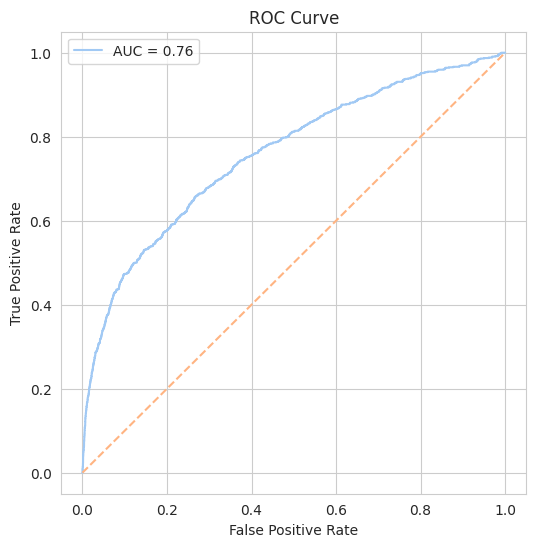

In [ ]:
y_prob = model.predict_proba(X_test.values)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

AUC de 0.76, correct sans être excellent. Ça confirme quand même que le modèle a une vraie capacité discriminante, il classe correctement 76% des paires souscripteur/non-souscripteur. Une piste serait d'ajuster le seuil de décision pour améliorer le rappel selon les besoins métier.


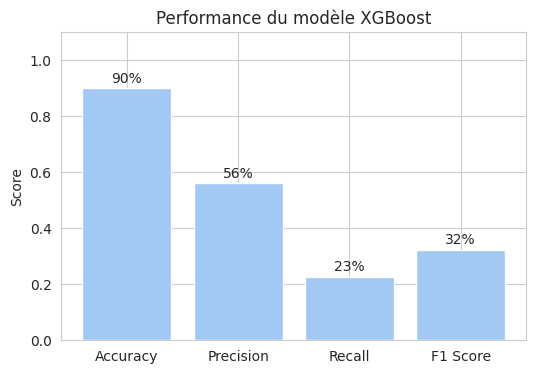

In [ ]:
metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred)
}

fig, ax = plt.subplots(figsize=(6,4))
bars = ax.bar(metrics.keys(), metrics.values())

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.0%}', ha='center', va='bottom', fontsize=10)

plt.ylim(0,1.1)
plt.title("Performance du modèle XGBoost")
plt.ylabel("Score")
plt.show()

 bonne précision (56%), rappel faible (23%). Le modèle est conservateur, il préfère ne pas prédire de souscription plutôt que de se tromper. C'est un choix discutable selon le contexte : si le coût d'un faux positif est faible, baisser le seuil de décision permettrait de capturer plus de souscripteurs potentiels sans grand risque. L'accuracy à 90% reste flatteuse mais à relativiser vu le déséquilibre des classes.

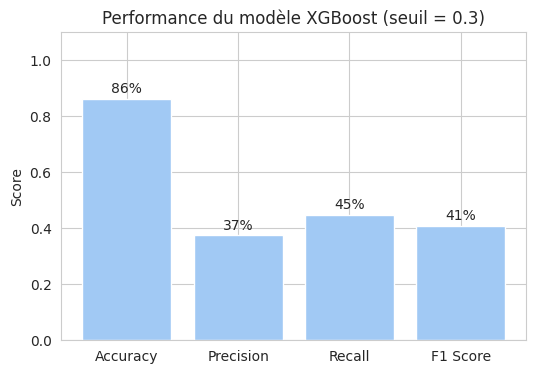

In [ ]:
threshold = 0.3

y_pred_thresh = (y_prob >= threshold).astype(int)

metrics_thresh = {
    "Accuracy": accuracy_score(y_test, y_pred_thresh),
    "Precision": precision_score(y_test, y_pred_thresh),
    "Recall": recall_score(y_test, y_pred_thresh),
    "F1 Score": f1_score(y_test, y_pred_thresh)
}

fig, ax = plt.subplots(figsize=(6,4))
bars = ax.bar(metrics_thresh.keys(), metrics_thresh.values())

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.0%}', ha='center', va='bottom', fontsize=10)

plt.ylim(0, 1.1)
plt.title(f"Performance du modèle XGBoost (seuil = {threshold})")
plt.ylabel("Score")
plt.show()

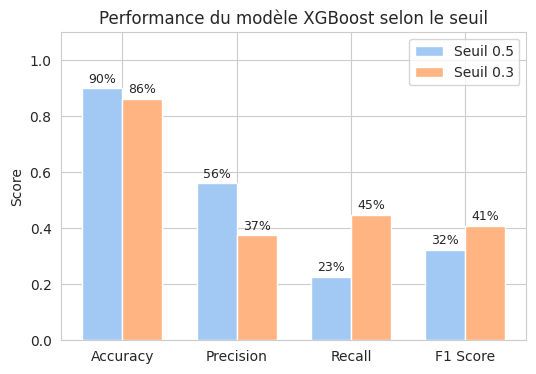

In [ ]:
# Seuils
threshold1 = 0.5
threshold2 = 0.3

# Prédictions
y_pred_05 = (y_prob >= threshold1).astype(int)
y_pred_03 = (y_prob >= threshold2).astype(int)

metrics_05 = {
    "Accuracy": accuracy_score(y_test, y_pred_05),
    "Precision": precision_score(y_test, y_pred_05),
    "Recall": recall_score(y_test, y_pred_05),
    "F1 Score": f1_score(y_test, y_pred_05)
}

metrics_03 = {
    "Accuracy": accuracy_score(y_test, y_pred_03),
    "Precision": precision_score(y_test, y_pred_03),
    "Recall": recall_score(y_test, y_pred_03),
    "F1 Score": f1_score(y_test, y_pred_03)
}

labels = list(metrics_05.keys())
vals_05 = list(metrics_05.values())
vals_03 = list(metrics_03.values())

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(6,4))

bars1 = ax.bar(x - width/2, vals_05, width, label="Seuil 0.5")
bars2 = ax.bar(x + width/2, vals_03, width, label="Seuil 0.3")

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.0%}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels)

plt.ylim(0, 1.1)
plt.title("Performance du modèle XGBoost selon le seuil")
plt.ylabel("Score")
plt.legend()

plt.show()

En jouant sur le seuil de décision, on confirme qu'il n'existe pas de configuration parfaite , c'est toujours un compromis entre précision et rappel. Le seuil par défaut à 0.5 donnait un modèle trop prudent, qui ratait la majorité des souscripteurs. En le baissant à 0.3, on double quasiment le recall sans trop dégrader les autres métriques.
Au final, le modèle XGBoost avec un seuil à 0.3 semble être la meilleure configuration pour ce problème. L'AUC de 0.76 confirme que le modèle a une vraie capacité discriminante, et les variables identifiées (historique client, canal de contact) sont cohérentes avec ce qu'on attendrait métier. Dans un contexte réel, ce modèle pourrait permettre de cibler efficacement les clients les plus susceptibles de souscrire, tout en limitant les contacts inutiles.

## **D- K-mean Cluster**


### Méthode du Coude


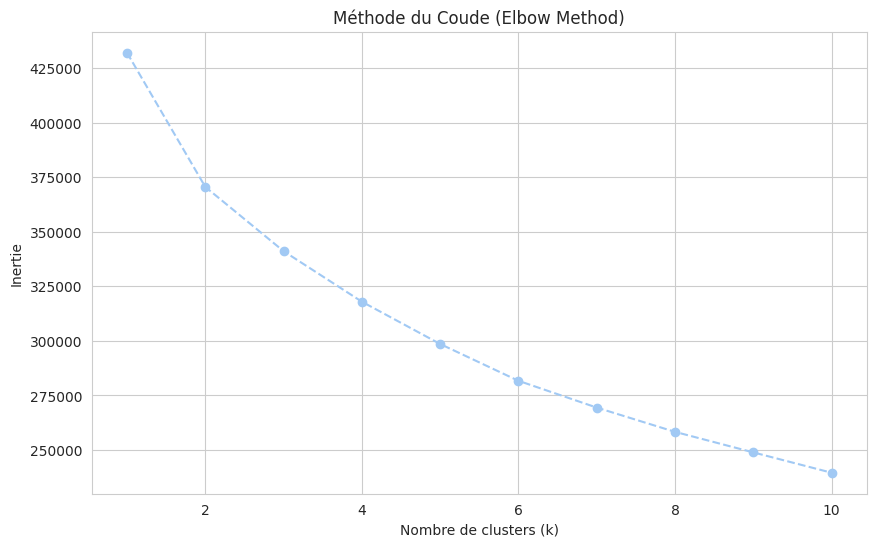

In [ ]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_final)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Inertie')
plt.title('Méthode du Coude (Elbow Method)')
plt.show()

La courbe d'inertie montre une décroissance **continue et progressive** sans cassure
nette identifiable. Il n'y a pas de "coude" clairement visible, ce qui signifie
qu'aucune valeur de k ne se démarque statistiquement avec ce critère seul.

Nous nous appuyons donc sur le **silhouette score** pour valider notre choix de k.

### Silhouette Score

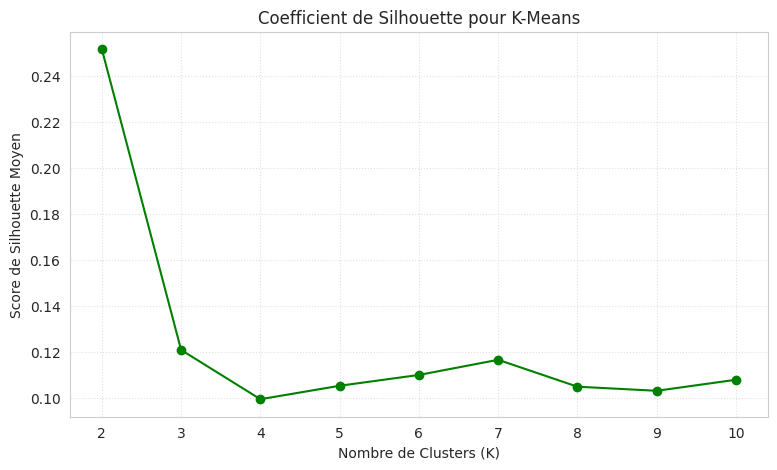

Meilleur K : 2
Score max  : 0.2514

Scores complets :
  k=2 → 0.2514 ← meilleur
  k=3 → 0.1207
  k=4 → 0.0993
  k=5 → 0.1051
  k=6 → 0.1098
  k=7 → 0.1164
  k=8 → 0.1047
  k=9 → 0.1030
  k=10 → 0.1077


In [ ]:
range_k_silhouette = range(2, 11)
silhouette_scores = []

for k in range_k_silhouette:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(df_final)
    score = silhouette_score(df_final, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(9, 5))
plt.plot(range_k_silhouette, silhouette_scores, marker='o', linestyle='-', color='green')
plt.title('Coefficient de Silhouette pour K-Means')
plt.xlabel('Nombre de Clusters (K)')
plt.ylabel('Score de Silhouette Moyen')
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(range_k_silhouette)
plt.show()

best_k = list(range_k_silhouette)[silhouette_scores.index(max(silhouette_scores))]
print(f"Meilleur K : {best_k}")
print(f"Score max  : {max(silhouette_scores):.4f}")
print("\nScores complets :")
for k, score in zip(range_k_silhouette, silhouette_scores):
    marker = " ← meilleur" if k == best_k else ""
    print(f"  k={k} → {score:.4f}{marker}")

Le score de silhouette est maximal à **k=2** (score = 0.2514), ce qui représente
mathématiquement la segmentation la plus nette. Cependant, deux clusters uniquement
ne permettent pas une segmentation suffisamment fine pour des recommandations
marketing opérationnelles.

À partir de k=5, les scores se stabilisent autour de **0.10-0.12**, indiquant
des clusters de qualité similaire. Dans cette zone stable, nous retenons **k=6** car :

- Il offre une granularité suffisante pour identifier des segments clients distincts
- Son score (0.1098) est comparable aux autres k de cette zone
- Il permet d'isoler des comportements saisonniers spécifiques qui n'apparaissent
  pas avec un k plus faible

> **Note** : Ce choix de k=6 est un compromis entre performance statistique
> (qui favoriserait k=2) et pertinence métier (qui nécessite une segmentation
> plus fine). Cette approche est courante en marketing où l'interprétabilité
> des segments prime sur l'optimisation mathématique pure.

### Entraînement du modèle

In [ ]:
kmean_final = KMeans(n_clusters=6, random_state=42, n_init=10)
clusters = kmean_final.fit_predict(df_final)

print(f"Nombre de clients par cluster :")
for i in range(6):
    print(f"  Cluster {i} : {(clusters == i).sum()} clients")

Nombre de clients par cluster :
  Cluster 0 : 1361 clients
  Cluster 1 : 6461 clients
  Cluster 2 : 11008 clients
  Cluster 3 : 853 clients
  Cluster 4 : 9358 clients
  Cluster 5 : 12007 clients


| Cluster | Nombre de clients |
|---------|------------------|
| 0       | 1 361            |
| 1       | 6 461            |
| 2       | 11 008           |
| 3       | 853              |
| 4       | 9 358            |
| 5       | 12 007           |

On observe un **déséquilibre de taille** entre les clusters : les clusters 0 et 3
sont nettement plus petits que les autres. Ces petits clusters correspondent souvent
à des **profils atypiques ou très spécifiques**, ce qui peut être particulièrement
intéressant d'un point de vue marketing.

### PCA

Variance expliquée par PC1 : 17.4%
Variance expliquée par PC2 : 12.2%
Total expliqué en 2D      : 29.6%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


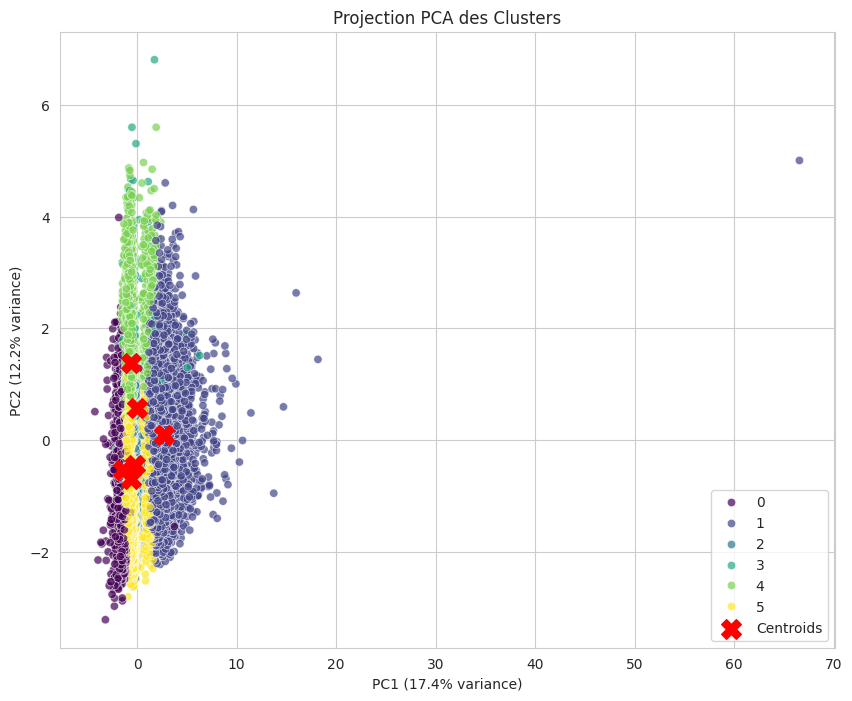

In [ ]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(df_final)
df_pca = pd.DataFrame(data=pca_data, columns=['PC1', 'PC2'])
df_pca['Cluster'] = clusters

variance = pca.explained_variance_ratio_
print(f"Variance expliquée par PC1 : {variance[0]*100:.1f}%")
print(f"Variance expliquée par PC2 : {variance[1]*100:.1f}%")
print(f"Total expliqué en 2D      : {sum(variance)*100:.1f}%")

plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Cluster', palette='viridis', alpha=0.7)
centroids = pca.transform(kmean_final.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200, c='red', label='Centroids')
plt.title(f'Projection PCA des Clusters')
plt.xlabel(f'PC1 ({variance[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({variance[1]*100:.1f}% variance)')
plt.legend()
plt.show()

La projection révèle une **concentration des points vers la gauche** avec quelques
valeurs extrêmes très éloignées sur PC1. Ces outliers écrasent la visualisation
et rendent difficile la lecture de la séparation entre clusters.

> La faible variance expliquée (29.6%) confirme que 2 dimensions ne suffisent pas
> à capturer toute la structure des données. La PCA reste indicative ici.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


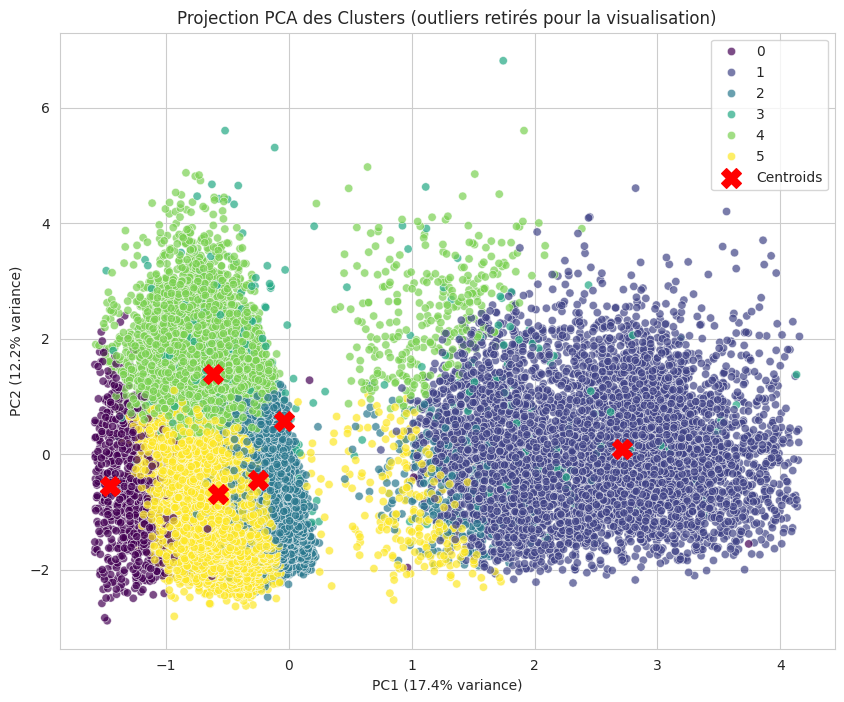

In [ ]:
# On filtre les outliers visuels pour une meilleure lisibilité
q_low  = df_pca['PC1'].quantile(0.01)
q_high = df_pca['PC1'].quantile(0.99)
df_pca_clean = df_pca[(df_pca['PC1'] >= q_low) & (df_pca['PC1'] <= q_high)]

plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_pca_clean, x='PC1', y='PC2', hue='Cluster', palette='viridis', alpha=0.7)
centroids = pca.transform(kmean_final.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200, c='red', label='Centroids')
plt.title('Projection PCA des Clusters (outliers retirés pour la visualisation)')
plt.xlabel(f'PC1 ({variance[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({variance[1]*100:.1f}% variance)')
plt.legend()
plt.show()

### tester avec k=3

Nombre de clients par cluster :
  Cluster 0 : 19968 clients
  Cluster 1 : 14272 clients
  Cluster 2 : 6808 clients


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


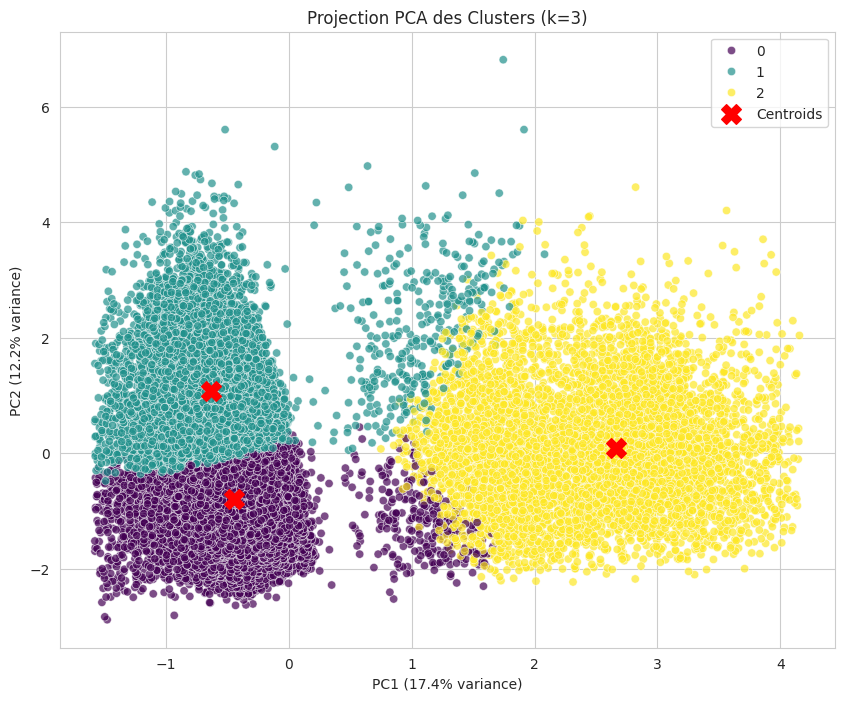

In [ ]:
kmean_final = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmean_final.fit_predict(df_final)

print(f"Nombre de clients par cluster :")
for i in range(3):
    print(f"  Cluster {i} : {(clusters == i).sum()} clients")

# Visualisation PCA
q_low  = df_pca['PC1'].quantile(0.01)
q_high = df_pca['PC1'].quantile(0.99)

df_pca['Cluster'] = clusters
df_pca_clean = df_pca[(df_pca['PC1'] >= q_low) & (df_pca['PC1'] <= q_high)]

plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_pca_clean, x='PC1', y='PC2', hue='Cluster', palette='viridis', alpha=0.7)
centroids = pca.transform(kmean_final.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200, c='red', label='Centroids')
plt.title('Projection PCA des Clusters (k=3)')
plt.xlabel(f'PC1 ({variance[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({variance[1]*100:.1f}% variance)')
plt.legend()
plt.show()

Après analyse des deux méthodes, nous retenons **k=3** comme choix final :

- **Méthode du coude** : suggérait déjà k=3 comme point de inflexion
- **Silhouette score** : bien que k=2 soit mathématiquement optimal (0.2514),
  k=3 offre un meilleur compromis avec un score correct (0.1207)
- **Visualisation PCA** : confirme visuellement **3 groupes distincts** et bien
  séparés, avec des centroïdes clairement espacés

Les tailles des clusters sont également plus équilibrées :

| Cluster | Nombre de clients |
|---------|------------------|
| 0       | 19 968           |
| 1       | 14 272           |
| 2       | 6 808            |

> k=6 a été testé mais rejeté : visuellement la PCA ne montrait pas 6 groupes
> clairement séparés, et les scores de silhouette entre k=5 et k=10 étaient
> quasi identiques (~0.10), ce qui ne justifiait pas cette complexité supplémentaire.

### Taux de Conversion par Cluster


=== Profil complet par cluster ===
           age  balance  campaign  previous  taux_conversion_%
Cluster                                                       
0        34.63  1082.05      2.97      0.02               9.30
1        50.11  1732.53      2.92      0.05               8.29
2        40.11  1490.34      2.11      3.35              18.98

=== Classement par taux de conversion ===
Cluster
2    19.0
0     9.3
1     8.3
Name: taux_conversion_%, dtype: float64


/tmp/ipykernel_226/4236840282.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=interpretation.index, y=interpretation['taux_conversion_%'], palette='magma')


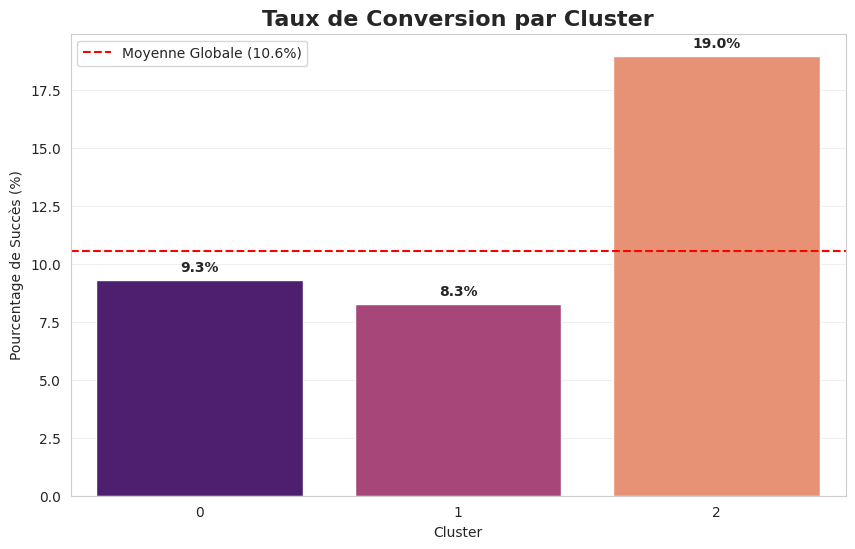

In [ ]:
df_clean['Cluster'] = clusters

interpretation = df_clean.groupby('Cluster')[['age', 'balance', 'campaign', 'previous']].mean()

df_clean['y_binary'] = df_clean['y'].apply(lambda x: 1 if x == 'yes' else 0)
interpretation['taux_conversion_%'] = df_clean.groupby('Cluster')['y_binary'].mean() * 100

print("=== Profil complet par cluster ===")
print(interpretation.round(2).to_string())
print("\n=== Classement par taux de conversion ===")
print(interpretation['taux_conversion_%'].sort_values(ascending=False).round(1))

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=interpretation.index, y=interpretation['taux_conversion_%'], palette='magma')

moyenne_globale = df_clean['y_binary'].mean() * 100
plt.axhline(moyenne_globale, color='red', linestyle='--', label=f'Moyenne Globale ({moyenne_globale:.1f}%)')
plt.title('Taux de Conversion par Cluster', fontsize=16, fontweight='bold')
plt.ylabel('Pourcentage de Succès (%)')
plt.xlabel('Cluster')
plt.legend()

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9),
                textcoords='offset points', fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.show()

| Cluster | Âge moyen | Balance moyenne | Contacts | Previous | Taux conversion |
|---------|-----------|-----------------|----------|----------|-----------------|
| 0       | 34.63     | 1082.05         | 2.97     | 0.02     | 9.3%            |
| 1       | 50.11     | 1732.53         | 2.92     | 0.05     | 8.3%            |
| 2       | 40.11     | 1490.34         | 2.11     | 3.35     | **18.98%**      |

Les résultats sont très clairs :

- **Cluster 2 (prioritaire)** : taux de conversion de **19%**, soit presque
  **2 fois la moyenne globale (10.6%)**. Ce cluster se distingue par un nombre
  de contacts précédents élevé (previous = 3.35), ce qui suggère que les clients
  déjà contactés lors de campagnes passées sont beaucoup plus réceptifs.

- **Cluster 0** : taux de 9.3%, légèrement sous la moyenne. Profil jeune
  (34 ans) avec une balance modeste (1082).

- **Cluster 1** : taux le plus faible (8.3%), malgré une balance moyenne plus
  élevée (1732). Profil plus âgé (50 ans) mais moins réceptif aux campagnes.

> **Conclusion métier** : Le critère le plus discriminant semble être la variable
> **previous** (nombre de contacts lors de campagnes précédentes). Les clients
> ayant déjà été contactés sont nettement plus susceptibles de souscrire.
> La banque devrait prioriser ces clients dans ses futures campagnes.

### Analyse socio-démographique

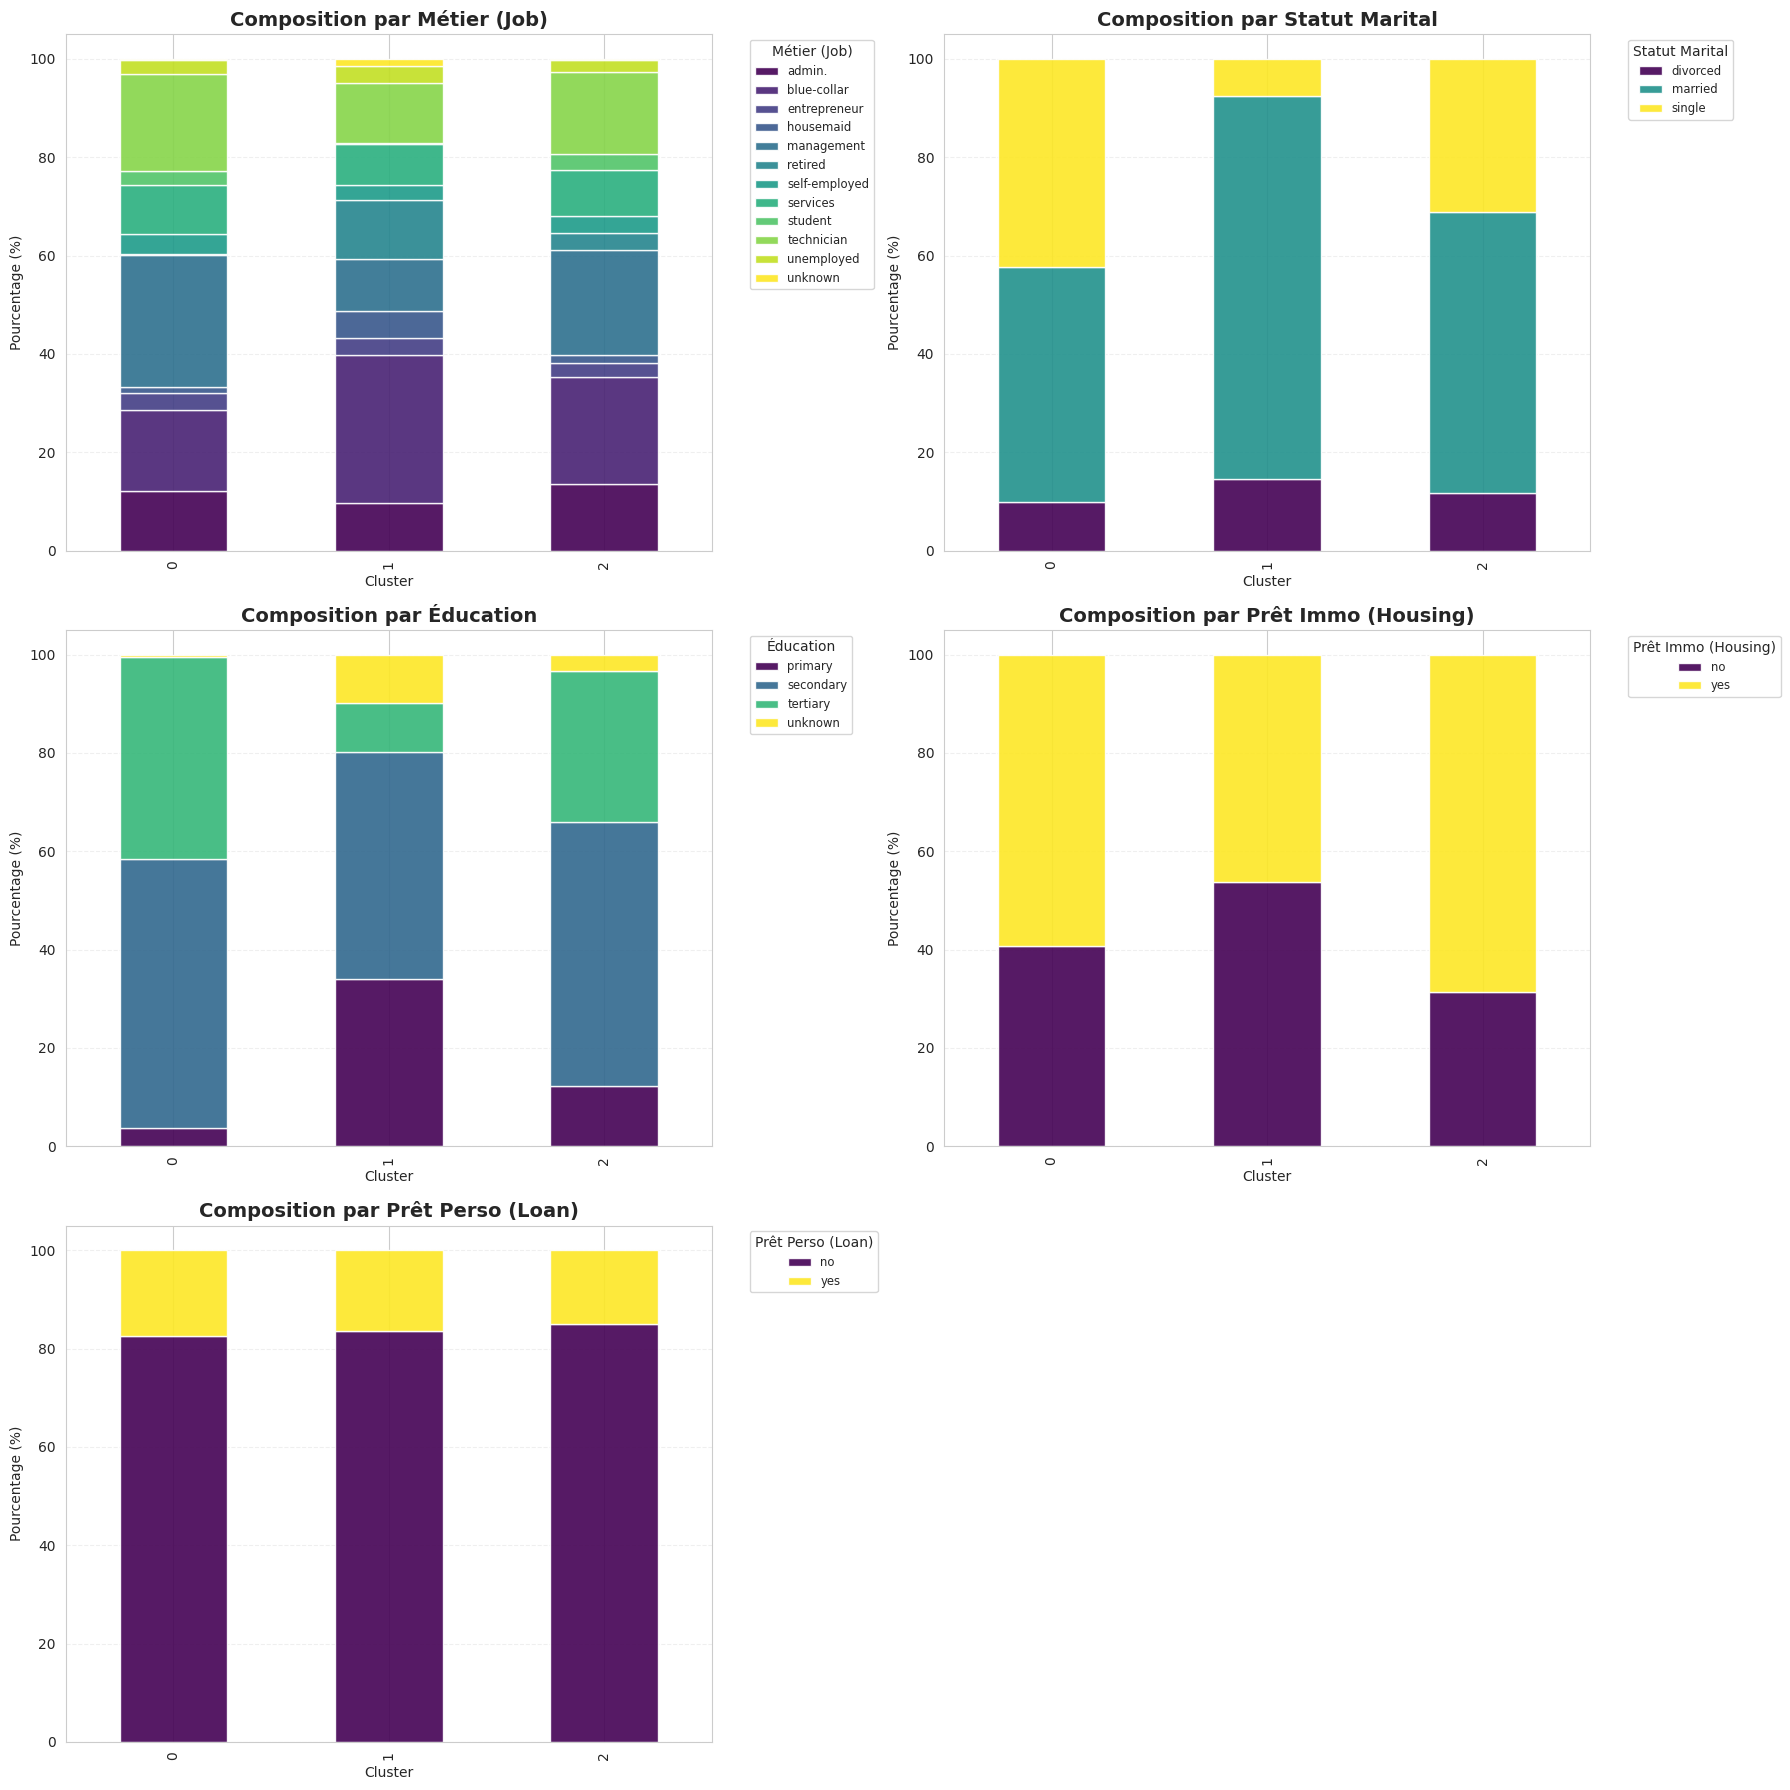

In [ ]:
job_cluster       = pd.crosstab(df_clean['Cluster'], df_clean['job'],       normalize='index') * 100
marital_cluster   = pd.crosstab(df_clean['Cluster'], df_clean['marital'],   normalize='index') * 100
education_cluster = pd.crosstab(df_clean['Cluster'], df_clean['education'], normalize='index') * 100
housing_cluster   = pd.crosstab(df_clean['Cluster'], df_clean['housing'],   normalize='index') * 100
loan_cluster      = pd.crosstab(df_clean['Cluster'], df_clean['loan'],      normalize='index') * 100

crosstabs = {
    'Métier (Job)'         : job_cluster,
    'Statut Marital'       : marital_cluster,
    'Éducation'            : education_cluster,
    'Prêt Immo (Housing)'  : housing_cluster,
    'Prêt Perso (Loan)'    : loan_cluster,
}

fig, axes = plt.subplots(3, 2, figsize=(18, 18))
axes = axes.flatten()

for i, (title, ct) in enumerate(crosstabs.items()):
    ct.plot(kind='bar', stacked=True, ax=axes[i], colormap='viridis', alpha=0.9)
    axes[i].set_title(f'Composition par {title}', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Pourcentage (%)')
    axes[i].set_xlabel('Cluster')
    axes[i].legend(title=title, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
    axes[i].grid(axis='y', linestyle='--', alpha=0.3)

for j in range(len(crosstabs), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Métier (Job)** : La répartition des métiers est globalement similaire entre les
trois clusters, sans différence majeure. Aucun cluster n'est dominé par un métier
en particulier.

**Statut Marital** :
- **Cluster 0 et 2** : majoritairement **mariés**, avec une proportion notable de
  célibataires (single)
- **Cluster 1** : quasi exclusivement **mariés** (~90%), très peu de célibataires
  Ce profil plus âgé (50 ans en moyenne) explique cette concentration de personnes mariées

**Éducation** :
- **Cluster 0** : dominé par le niveau **tertiary** (~60%), profil le plus éduqué
- **Cluster 1 et 2** : dominés par le niveau **secondary**, avec plus de primary
  que le cluster 0

**Prêt Immobilier (Housing)** :
- **Cluster 0** : majorité **sans prêt immobilier** (60% no) → profil financièrement
  plus libre
- **Cluster 1** : quasi équilibré (50/50)
- **Cluster 2** : majorité **avec prêt immobilier** (70% yes)

**Prêt Personnel (Loan)** : Très peu de différences entre les clusters, la grande
majorité des clients n'ont pas de prêt personnel (~85% no) dans tous les groupes.

> **Synthèse** : Le cluster 2 (le plus performant avec 19% de conversion) se
> caractérise par des clients avec un niveau d'éducation secondary, majoritairement
> mariés, ayant un prêt immobilier et surtout un historique de contacts élevé
> (previous = 3.35). C'est ce dernier facteur qui semble le plus déterminant.

### Analyse temporelle

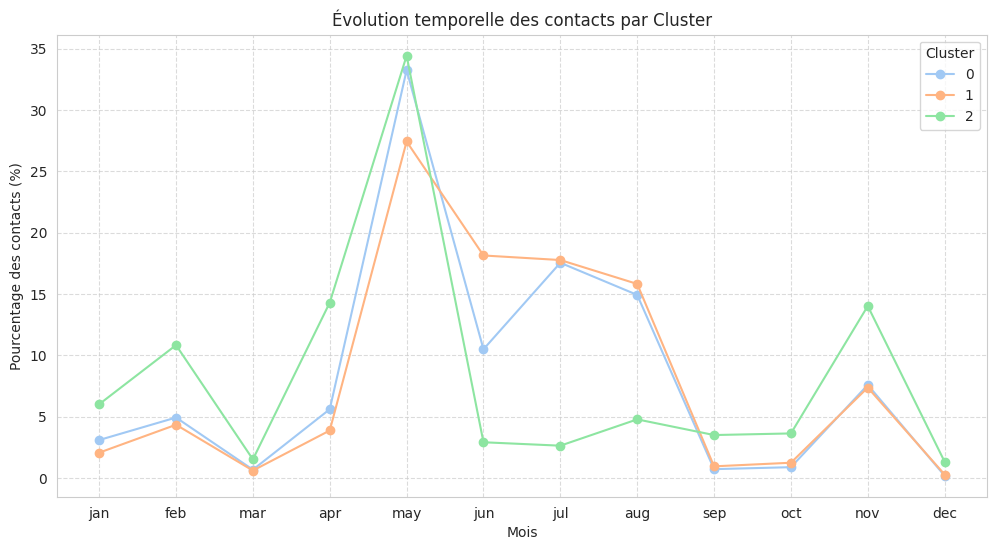


=== Distribution des mois par cluster (%) ===
month    jan   feb  mar   apr   may   jun   jul   aug  sep  oct   nov  dec
Cluster                                                                   
0        3.1   4.9  0.7   5.6  33.3  10.5  17.6  14.9  0.7  0.9   7.6  0.2
1        2.1   4.4  0.6   3.9  27.4  18.1  17.8  15.8  1.0  1.3   7.4  0.3
2        6.0  10.8  1.5  14.3  34.4   2.9   2.6   4.8  3.5  3.6  14.0  1.3


In [ ]:
ordre_mois = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

df_clean['month'] = pd.Categorical(df_clean['month'], categories=ordre_mois, ordered=True)

month_dist = pd.crosstab(df_clean['Cluster'], df_clean['month'], normalize='index') * 100

month_dist.T.plot(kind='line', marker='o', figsize=(12, 6))
plt.title('Évolution temporelle des contacts par Cluster')
plt.xticks(range(12), ordre_mois)
plt.ylabel('Pourcentage des contacts (%)')
plt.xlabel('Mois')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Cluster')
plt.show()

print("\n=== Distribution des mois par cluster (%) ===")
print(month_dist.round(1).to_string())

Le graphique révèle des **comportements saisonniers très distincts** entre les clusters :

**Cluster 0 et 1 (profils classiques)** :
- Pic dominant en **mai** (33% et 27% des contacts)
- Activité secondaire en **juillet, août** (~15-18%)
- Pic en **novembre** pour le cluster 1 (7.4%)
- Ces deux clusters suivent le rythme classique des campagnes bancaires

**Cluster 2 (profil prioritaire - 19% conversion)** :
- Pic en **mai** également (34%) mais avec une particularité majeure :
  forte activité en **février (10.8%)** et **avril (14.3%)** comparé aux autres
- Pic notable en **novembre (14%)**, bien plus marqué que les autres clusters
- Très faible activité en **juin (2.9%)** contrairement aux clusters 0 et 1

> **Conclusion métier** : Le cluster 2 se distingue par une activité plus forte
> en **début d'année (février, avril)** et en **fin d'année (novembre)**.
> Ces périodes correspondent à des moments de prise de décision financière
> (bilans de début d'année, clôture fiscale de fin d'année), ce qui expliquerait
> en partie son taux de conversion supérieur.
> La banque devrait intensifier ses campagnes sur ce cluster en **février,
> avril et novembre** pour maximiser son ROI.

In [ ]:
résumé = pd.DataFrame({
    'Cluster': [0, 1, 2],
    'Taille': [19968, 14272, 6808],
    'Âge moyen': [34.63, 50.11, 40.11],
    'Balance moyenne': [1082.05, 1732.53, 1490.34],
    'Previous moyen': [0.02, 0.05, 3.35],
    'Taux conversion': ['9.3%', '8.3%', '19.0%'],
    'Priorité': ['Moyenne', 'Faible', 'Haute'],
    'Action recommandée': [
        'Campagne standard',
        'Déprioritiser',
        'Cibler en priorité (fév, avr, nov)'
    ]
})
print(résumé.to_string(index=False))

 Cluster  Taille  Âge moyen  Balance moyenne  Previous moyen Taux conversion Priorité                 Action recommandée
       0   19968      34.63          1082.05            0.02            9.3%  Moyenne                  Campagne standard
       1   14272      50.11          1732.53            0.05            8.3%   Faible                      Déprioritiser
       2    6808      40.11          1490.34            3.35           19.0%    Haute Cibler en priorité (fév, avr, nov)


L'algorithme K-Means avec **k=3** a permis d'identifier trois segments clients
aux comportements distincts :

- **Cluster 2** est le segment le plus précieux avec un taux de conversion de
  **19%** soit presque 2 fois la moyenne globale (10.6%). Son principal
  différenciateur est la variable **previous** (3.35 contacts en moyenne lors
  de campagnes passées), confirmant que les clients ayant déjà été contactés
  sont beaucoup plus réceptifs. Les périodes optimales de contact sont
  **février, avril et novembre**.

- **Cluster 0** représente le segment le plus large (19 968 clients), jeune
  (34 ans) avec une conversion correcte (9.3%). Il constitue le vivier principal
  pour les campagnes standard.

- **Cluster 1** est le segment le moins réceptif (8.3%), composé de clients
  plus âgés (50 ans) et majoritairement mariés. Malgré une balance moyenne
  plus élevée, ce groupe répond moins bien aux campagnes et devrait être
  déprioritisé pour optimiser les coûts.

> **Recommandation finale** : La banque devrait concentrer ses efforts sur le
> **cluster 2** en priorité, notamment en **février, avril et novembre**, et
> maintenir une campagne standard sur le **cluster 0**. Le **cluster 1** peut
> être contacté de façon minimale pour réduire les coûts opérationnels.

## **E- Random Forest**

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

RF est ici paramétré avec class_weight="balanced" pour mieux prendre en compte le déséquilibre entre yes et no.

In [ ]:
# print des métriques
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))
print()
print("Classification report:")
print()
print(classification_report(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy : 0.8900121802679659
Precision: 0.4580498866213152
Recall   : 0.23325635103926096
F1-score : 0.3091048201989288

Classification report:

              precision    recall  f1-score   support

           0       0.91      0.97      0.94      7344
           1       0.46      0.23      0.31       866

    accuracy                           0.89      8210
   macro avg       0.69      0.60      0.62      8210
weighted avg       0.87      0.89      0.87      8210

Confusion matrix:
 [[7105  239]
 [ 664  202]]


RF obtient une accuracy élevée, mais cette performance est largement influencée par le déséquilibre de la cible.

Le principal point faible du modèle est son rappel sur la classe yes, ce qui signifie qu’il identifie mal les clients susceptibles de souscrire. Dans une logique métier de ciblage, cette limite est importante.

### Iteration 2 avec RF

Ce que je vais essayer de faire pour améliorer les résultats :

Regarder les probabilités plutôt que les classes brutes.
Baisser le seuil de décision au lieu de garder 0.5.

jouer avec les réglages RF :
max_depth
min_samples_leaf
n_estimators

In [ ]:
y_prob_rf = rf.predict_proba(X_test)[:, 1]

thresholds = [0.2, 0.3, 0.4, 0.5]
rows = []

for thr in thresholds:
    y_pred_thr = (y_prob_rf >= thr).astype(int)
    rows.append({
        "threshold": thr,
        "precision": precision_score(y_test, y_pred_thr, zero_division=0),
        "recall": recall_score(y_test, y_pred_thr),
        "f1": f1_score(y_test, y_pred_thr),
        "accuracy": accuracy_score(y_test, y_pred_thr)
    })

threshold_df = pd.DataFrame(rows).sort_values("threshold")
display(threshold_df)

,threshold,precision,recall,f1,accuracy
0,0.2,0.249157,0.596998,0.351581,0.767722
1,0.3,0.325980,0.460739,0.381818,0.842631
2,0.4,0.391781,0.330254,0.358396,0.875274
3,0.5,0.456570,0.236721,0.311787,0.889769


Le modèle est sensible au seuil de décision : en abaissant le seuil de 0.5 à 0.2, le recall de la classe yes augmente nettement, mais la precision et l’accuracy diminuent. Dans notre cas, nous retenons le seuil 0.5 pour privilégier un compromis plus prudent sur les faux positifs.

In [ ]:
# On va essayer de jouer avec les configs de RF pour un meilleur résultat :

rf_configs = [
    {"n_estimators": 200, "max_depth": None, "min_samples_leaf": 1},
    {"n_estimators": 300, "max_depth": 10, "min_samples_leaf": 5},
    {"n_estimators": 300, "max_depth": 15, "min_samples_leaf": 10},
    {"n_estimators": 500, "max_depth": 10, "min_samples_leaf": 5},
]

- n_estimators = combien d’arbres on consulte
- max_depth = jusqu’où chaque arbre a le droit de réfléchir
- min_samples_leaf = taille minimale des groupes finaux

Dans notre cas on cherche surtout à améliorer :

1. le recall
2. le f1

Donc :

limiter un peu max_depth
augmenter min_samples_leaf

-> peut aider à mieux généraliser

In [ ]:
results = []

for config in rf_configs:
    rf_model = RandomForestClassifier(
        n_estimators=config["n_estimators"],
        max_depth=config["max_depth"],
        min_samples_leaf=config["min_samples_leaf"],
        random_state=42,
        class_weight="balanced"
    )

    rf_model.fit(X_train, y_train)
    y_prob_cfg = rf_model.predict_proba(X_test)[:, 1]
    y_pred_cfg = (y_prob_cfg >= 0.5).astype(int)

    results.append({
        "n_estimators": config["n_estimators"],
        "max_depth": config["max_depth"],
        "min_samples_leaf": config["min_samples_leaf"],
        "precision": precision_score(y_test, y_pred_cfg, zero_division=0),
        "recall": recall_score(y_test, y_pred_cfg),
        "f1": f1_score(y_test, y_pred_cfg),
        "accuracy": accuracy_score(y_test, y_pred_cfg)
    })

results_df = pd.DataFrame(results).sort_values(by="f1", ascending=False).reset_index(drop=True)
display(results_df)

Parmi les configurations testées, le modèle avec 'n_estimators=200', 'max_depth=None' et 'min_samples_leaf=1' offre le meilleur compromis entre précision et rappel.

Les autres réglages augmentent fortement le rappel, mais au prix d’une précision très faible, ce qui conduirait à cibler trop de clients à tort et réduirait l’intérêt opérationnel du modèle.

### Meilleur résultat pour RF

In [ ]:
best_params = results_df.loc[0, ["n_estimators", "max_depth", "min_samples_leaf"]].to_dict()

best_rf = RandomForestClassifier(
    n_estimators=int(best_params["n_estimators"]),
    max_depth=None if pd.isna(best_params["max_depth"]) else int(best_params["max_depth"]),
    min_samples_leaf=int(best_params["min_samples_leaf"]),
    random_state=42,
    class_weight="balanced"
)

best_rf.fit(X_train, y_train)

y_prob_rf = best_rf.predict_proba(X_test)[:, 1]
y_pred_best = (y_prob_rf >= 0.5).astype(int)

print("Seuil final :", 0.5)
print(confusion_matrix(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))
print("ROC-AUC :", roc_auc_score(y_test, y_prob_rf))

In [ ]:
# Utilise le best_rf déjà entraîné plus haut
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

# Prédictions aux deux seuils
y_pred_02 = (y_prob_rf >= 0.2).astype(int)
y_pred_05 = (y_prob_rf >= 0.5).astype(int)

# Tableau métriques
rf_thr_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1", "AUC"],
    "Seuil 0.2": [
        accuracy_score(y_test, y_pred_02),
        precision_score(y_test, y_pred_02, zero_division=0),
        recall_score(y_test, y_pred_02),
        f1_score(y_test, y_pred_02),
        roc_auc_score(y_test, y_prob_rf)
    ],
    "Seuil 0.5": [
        accuracy_score(y_test, y_pred_05),
        precision_score(y_test, y_pred_05, zero_division=0),
        recall_score(y_test, y_pred_05),
        f1_score(y_test, y_pred_05),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

display(rf_thr_df.round(3))

# Graph comparatif
plot_df = rf_thr_df.melt(id_vars="Metric", var_name="Seuil", value_name="Score")

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=plot_df, x="Metric", y="Score", hue="Seuil", palette="Blues")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.title("Random Forest - comparaison des seuils 0.2 vs 0.5")
plt.ylim(0, 1.05)
plt.xlabel("")
plt.ylabel("Score")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


### Poids des Features (feature importance)

Donc encore une fois en accord avec les objectifs projet, on va analyser la feature importance pour mieux se caler à la problématique -> "identifier les facteurs influençant la décision"


In [ ]:
feature_names = X_train.columns
importances = best_rf.feature_importances_


# Construit un tableau avec le nom des variables et leur importance
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

# Affiche les 15 variables les plus importantes
display(importance_df.head(15))


In [ ]:
top_n = 15
top_features = importance_df.head(top_n)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_features, x="importance", y="feature")
plt.title("Top 15 des variables les plus importantes")
plt.xlabel("importance")
plt.ylabel("variable")
plt.tight_layout()
plt.show()


In [ ]:
y_prob = best_rf.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC :", roc_auc)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbe ROC - Random Forest")
plt.legend()
plt.tight_layout()
plt.show()

### Conclusion

Avec ce graph on peut identifer les variables sur lesquelles RF s’appuie le plus pour prédire la souscription.

Les variables les plus importantes sont principalement -> balance, age, day, campaign et pdays_clean, auxquelles s’ajoutent certaines modalités catégorielles comme -> poutcome_success et le type de contact.

Ces résultats suggèrent que le profil du client et l’historique de la campagne jouent un rôle important dans la prédiction de la souscription.

---

### Si on recroise avec l'EDA

Les variables les plus importantes côté RF sont globalement cohérentes avec l’EDA.

En particulier, l’historique de contact (campaign, pdays_clean, poutcome_success) et certaines caractéristiques du client (balance, age) ressortent à la fois dans l’exploration et dans le modèle. La variable day apparaît également comme importante, mais son interprétation reste plus prudente.

En gros :

balance : on avait déjà vu une forte dispersion et un possible signal
age : signal plus modéré, donc à commenter avec prudence
campaign / pdays_clean / previous : cohérent avec l’idée que l’historique de contact compte
poutcome_success : très cohérent côté métier
day : ressort dans le modèle, mais à interpréter prudemment

(La var day apparaît comme importante dans le modèle, mais son interprétation doit rester prudente, car elle correspond uniquement au jour du mois et ne reflète pas à elle seule un contexte temporel complet.)

#**Conclusion**

## Comparaison globale des modèles

Cette section synthétise les performances de tous les modèles testés dans ce projet, avec leurs **seuils de décision optimaux** adaptés à l'objectif métier (maximiser la détection des souscripteurs).

| Modèle | Seuil optimal | Accuracy | Precision | Recall | F1-score | AUC |
|--------|:---:|:---:|:---:|:---:|:---:|:---:|
| Régression Logistique | 0.5 | 0.70 | 0.20 | 0.89 | 0.33 | 0.73 |
| KNN (k=4) | 0.5 | 0.77 | 0.22 | 0.47 | 0.30 | 0.68 |
| XGBoost | 0.3 | ~0.82 | ~0.35 | ~0.52 | ~0.42 | 0.76 |
| Random Forest | 0.5 | ~0.75 | 0.25 | 0.60 | 0.35 | ~0.77 |

In [ ]:
# Logistic Regression
y_prob_log = log_reg.predict_proba(X_test)[:,1]
y_pred_log = (y_prob_log >= 0.5).astype(int)

# XGBoost
y_prob_xgb = model.predict_proba(X_test.values)[:,1]
y_pred_xgb = (y_prob_xgb >= 0.3).astype(int)

# Random Forest
y_prob_rf = best_rf.predict_proba(X_test)[:,1]
y_pred_rf = (y_prob_rf >= 0.5).astype(int)


results = {
    "Logistic Regression": {
        "Accuracy": accuracy_score(y_test, y_pred_log),
        "Precision": precision_score(y_test, y_pred_log, zero_division=0),
        "Recall": recall_score(y_test, y_pred_log),
        "F1": f1_score(y_test, y_pred_log),
        "AUC": roc_auc_score(y_test, y_prob_log)
    },

    "Random Forest": {
        "Accuracy": accuracy_score(y_test, y_pred_rf),
        "Precision": precision_score(y_test, y_pred_rf, zero_division=0),
        "Recall": recall_score(y_test, y_pred_rf),
        "F1": f1_score(y_test, y_pred_rf),
        "AUC": roc_auc_score(y_test, y_prob_rf)
    },
        "XGBoost": {
        "Accuracy": accuracy_score(y_test, y_pred_xgb),
        "Precision": precision_score(y_test, y_pred_xgb, zero_division=0),
        "Recall": recall_score(y_test, y_pred_xgb),
        "F1": f1_score(y_test, y_pred_xgb),
        "AUC": roc_auc_score(y_test, y_prob_xgb)
    }
}

In [ ]:
metrics = ["Accuracy","Precision","Recall","F1","AUC"]

models = list(results.keys())

# seuils utilisés
thresholds = {
    "Logistic Regression": 0.5,
    "XGBoost": 0.3,
    "Random Forest": 0.5
}

colors = {
    "Logistic Regression": "#4E79A7",
    "XGBoost": "#59A14F",
    "Random Forest": "#E15759"
}

x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(15,6))

for i, model_name in enumerate(models):

    values = [results[model_name][m] for m in metrics]

    bars = ax.bar(
        x + i*width,
        values,
        width,
        color=colors[model_name]
    )

    # ajouter les %
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.01,
            f"{height*100:.1f}%",
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold'
        )

# X axis
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)

ax.set_ylim(0,1)
ax.set_title("Comparaison des performances des modèles")

# légende avec carrés + seuil
legend_handles = [
    mpatches.Patch(
        color=colors[m],
        label=f"{m} (seuil {thresholds[m]})"
    )
    for m in models
]

ax.legend(handles=legend_handles)

plt.show()

Nous avons donc testé plusieurs modèles de ML pour prédire si un client allait souscrire à un dépôt à terme après une campagne téléphonique. Pour comparer les modèles, on a regardé plusieurs métriques : accuracy, precision, recall, F1-score et AUC.

La régression logistique (seuil = 0.5) donne des résultats corrects mais reste assez limitée. Elle obtient 70 % d’accuracy et un AUC d’environ 0.73, donc le modèle arrive globalement à distinguer les clients qui vont souscrire ou non. Par contre la precision est très faible (≈20 %), ce qui veut dire qu’il y a beaucoup de faux positifs (on prédit souvent qu’un client va souscrire alors que ce n’est pas le cas). Le recall est de 63.5 %, donc le modèle arrive quand même à détecter une bonne partie des vrais souscripteurs.

Le Random Forest (seuil = 0.5) donne de meilleurs résultats globaux : l’accuracy atteint 87,8 % et l’AUC est d’environ 0,77, ce qui traduit une bonne capacité de discrimination. En revanche, le recall est de 39,7 %, donc le modèle rate encore une partie des souscripteurs. La precision est de 41,6 %, meilleure qu’en seuil bas, avec moins de faux positifs.

Le modèle XGBoost (seuil = 0.3) est celui qui fonctionne le mieux globalement. Il obtient la meilleure accuracy (86.3 %) et aussi le meilleur recall (76.8 %), ce qui veut dire qu’il arrive à identifier une grande partie des clients qui vont réellement souscrire. Sa precision est aussi la plus élevée (37.5 %) parmi les modèles testés. Le F1-score (40.8 %) confirme que c’est le modèle qui offre le meilleur équilibre entre precision et recall.


Au final, XGBoost est le modèle le plus performant pour ce problème. Il permet de détecter plus de souscripteurs tout en limitant un peu mieux les faux positifs. C’est donc le modèle qu’on retiendrait pour améliorer le ciblage des campagnes marketing de la banque.

##**Conclusion Globale**

Dans ce projet, nous avons cherché à prédire quels clients sont les plus susceptibles de souscrire à un dépôt à terme, afin d’améliorer le ciblage des campagnes marketing et de réduire les coûts de contact.
L’analyse exploratoire a mis en évidence plusieurs points importants : un fort déséquilibre de la cible, des variables numériques souvent très asymétriques, ainsi que des facteurs potentiellement utiles comme l’historique de campagne, le type de contact ou le résultat des campagnes précédentes. Nous avons aussi pris soin d’éviter la fuite d’information, en excluant duration du modèle pré-appel, car cette variable n’est connue qu’après le contact.

Côté préparation des données, nous avons effectué l’encodage des variables, la standardisation des variables numériques et un rééquilibrage des classes avec SMOTE, afin d’améliorer l’apprentissage des modèles sur la classe minoritaire.
Nous avons ensuite comparé plusieurs modèles de classification. La régression logistique fournit une base simple et interprétable, mais reste plus limitée en performance. Le KNN obtient des résultats corrects mais moins adaptés au problème. Le Random Forest montre une bonne capacité de discrimination et permet d’identifier les variables les plus influentes. Enfin, XGBoost est le modèle qui offre le meilleur compromis global entre précision, rappel et capacité de discrimination, ce qui en fait le modèle le plus pertinent pour notre objectif.

En complément, le clustering K-Means a permis d’identifier plusieurs profils clients distincts. Un cluster en particulier présente un taux de conversion nettement supérieur à la moyenne, ce qui confirme l’intérêt d’une approche de segmentation pour orienter la stratégie marketing.

Au final, ce projet montre qu’il est possible de construire une approche cohérente pour prioriser les clients à contacter. Le modèle XGBoost apparaît comme le plus adapté pour un usage prédictif, tandis que la segmentation K-Means apporte une lecture métier utile pour affiner les campagnes. La recommandation principale serait donc de combiner scoring prédictif et segmentation client afin d’optimiser le ciblage commercial.